<a href="https://colab.research.google.com/github/Likhithatugiti/Open_iit/blob/main/updated_notebook_aaryana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:

"""# Cell 2: Load data
df = pd.read_csv('../data/netflix_titles.csv')"""

"# Cell 2: Load data\ndf = pd.read_csv('../data/netflix_titles.csv')"

In [ ]:
#loading the dataset
df = pd.read_csv('/content/netflix_titles.csv')

In [ ]:
# Cell 3: Initial inspection
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic info:")
df.info()

Dataset Shape: (8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Data types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-nul

METADATA ANALYSIS:



Missing Values:
              Missing_Count  Percentage
director               2634   29.908028
country                 831    9.435676
cast                    825    9.367549
date_added               10    0.113546
rating                    4    0.045418
duration                  3    0.034064
show_id                   0    0.000000
type                      0    0.000000
title                     0    0.000000
release_year              0    0.000000
listed_in                 0    0.000000
description               0    0.000000


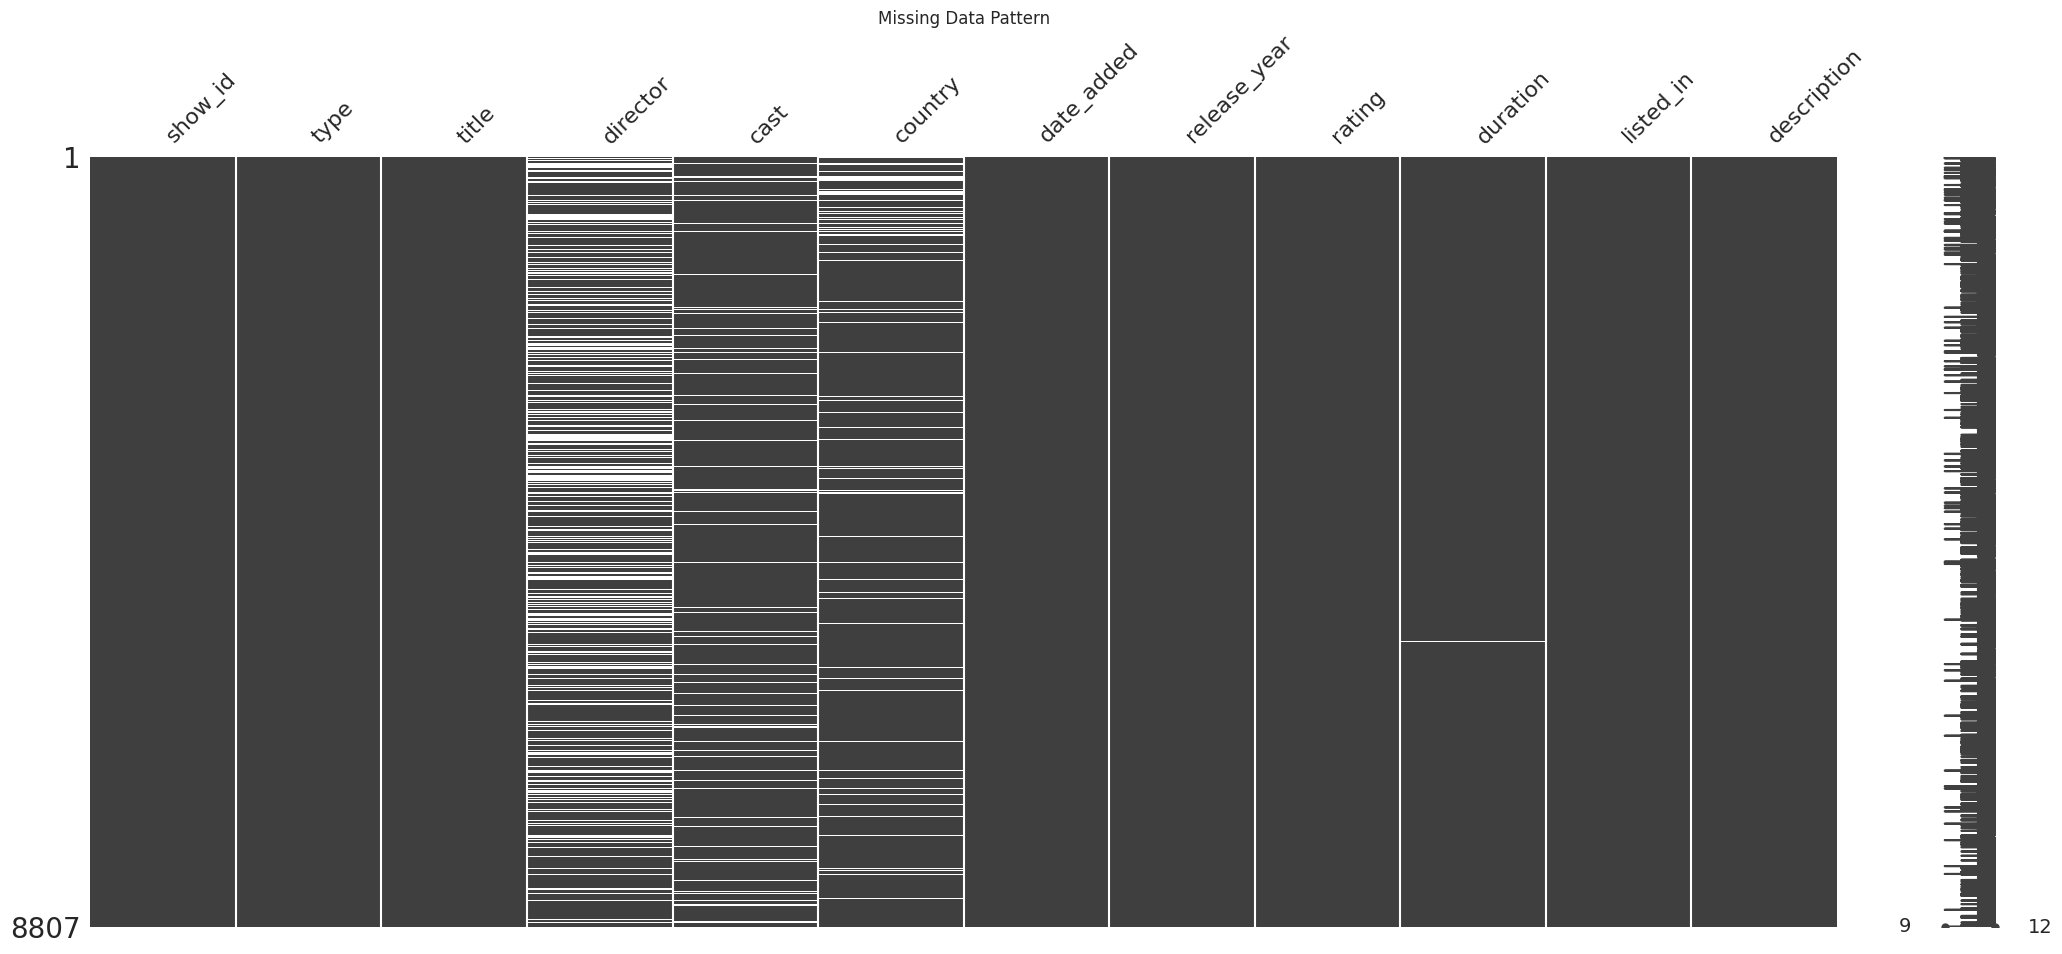

In [ ]:
# Cell 4: Missing values
import os

# Define the directory for visualizations
viz_dir = '/content/visualizations'
# Create the directory if it doesn't exist
os.makedirs(viz_dir, exist_ok=True)

print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print(missing_df)

# Visualize
import missingno as msno
msno.matrix(df)
plt.title('Missing Data Pattern')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '01_missing_data_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

Missing data analysis:

MISSING DATA PATTERN ANALYSIS

1. Missing Data by Content Type:
         director  cast  country  date_added  rating
type                                                
Movie         188   475      440           0       2
TV Show      2446   350      391          10       2

2. Missing Data by Top 10 Countries:

United States:
  Missing director: 27.3%
  Missing cast: 11.7%

India:
  Missing director: 8.4%
  Missing cast: 3.3%

United Kingdom:
  Missing director: 49.4%
  Missing cast: 16.2%

Japan:
  Missing director: 65.3%
  Missing cast: 2.0%

South Korea:
  Missing director: 75.4%
  Missing cast: 1.5%

Canada:
  Missing director: 34.3%
  Missing cast: 10.5%

Spain:
  Missing director: 26.9%
  Missing cast: 12.4%

France:
  Missing director: 34.7%
  Missing cast: 14.5%

Mexico:
  Missing director: 35.5%
  Missing cast: 7.3%

Egypt:
  Missing director: 15.1%
  Missing cast: 0.9%

3. Missing Data Correlation:


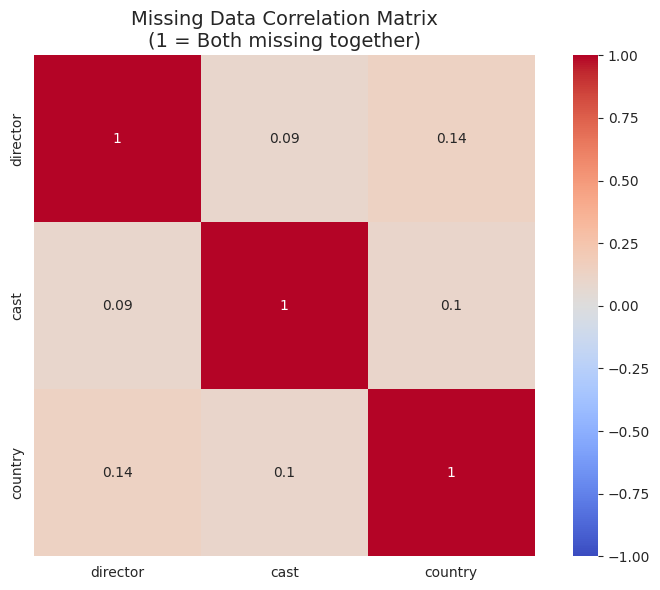


4. Data Quality Trend Over Time:


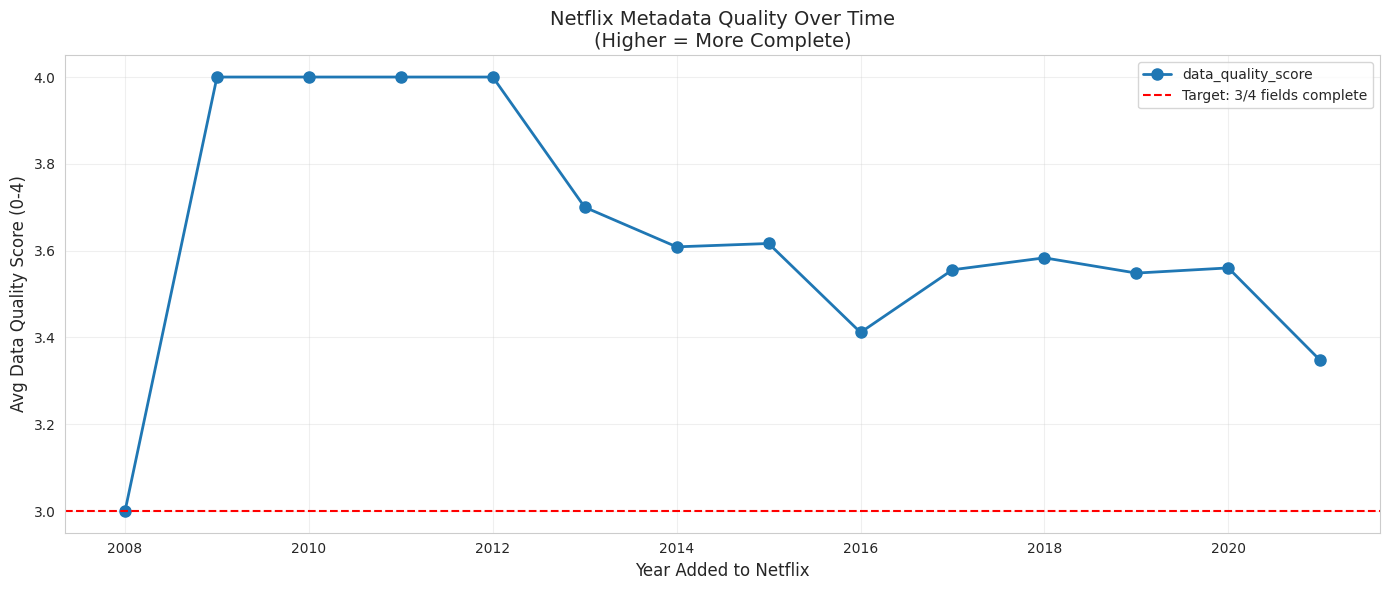

In [ ]:
# Add after your current missing value analysis

# ============================================
# DEEP DIVE: Missing Data Pattern Analysis
# ============================================

import os

# Define the directory for visualizations
viz_dir = '/content/visualizations'
# Create the directory if it doesn't exist
os.makedirs(viz_dir, exist_ok=True)

print("="*60)
print("MISSING DATA PATTERN ANALYSIS")
print("="*60 + "\n")

# 1. Missing data by content type
print("1. Missing Data by Content Type:")
missing_by_type = df.groupby('type').apply(
    lambda x: x.isnull().sum()
)[['director', 'cast', 'country', 'date_added', 'rating']]

print(missing_by_type)

# 2. Missing data by country (top 10)
print("\n2. Missing Data by Top 10 Countries:")
top_countries = df['country'].value_counts().head(10).index

for country in top_countries:
    country_data = df[df['country'] == country]
    missing_pct = (country_data.isnull().sum() / len(country_data) * 100)
    print(f"\n{country}:")
    print(f"  Missing director: {missing_pct['director']:.1f}%")
    print(f"  Missing cast: {missing_pct['cast']:.1f}%")

# 3. Missing data correlation
print("\n3. Missing Data Correlation:")
missing_matrix = df[['director', 'cast', 'country']].isnull().astype(int)
missing_corr = missing_matrix.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)
plt.title('Missing Data Correlation Matrix\n(1 = Both missing together)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'missing_data_correlation.png'), dpi=300, bbox_inches='tight')
plt.show()

# 4. Data quality score by year
print("\n4. Data Quality Trend Over Time:")
df['data_quality_score'] = df[['director', 'cast', 'country', 'rating']].notna().sum(axis=1)

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
quality_by_year = df.groupby('year_added')['data_quality_score'].mean()

plt.figure(figsize=(14, 6))
quality_by_year.plot(kind='line', marker='o', linewidth=2, markersize=8)
plt.xlabel('Year Added to Netflix', fontsize=12)
plt.ylabel('Avg Data Quality Score (0-4)', fontsize=12)
plt.title('Netflix Metadata Quality Over Time\n(Higher = More Complete)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=3, color='red', linestyle='--', label='Target: 3/4 fields complete')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'data_quality_trend.png'), dpi=300, bbox_inches='tight')
plt.show()

Data Cleaning

In [ ]:
# Create a copy for analysis
df_clean = df.copy()

# Handle missing values strategically
df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['date_added'] = df_clean['date_added'].fillna('Not Available')
df_clean['rating'] = df_clean['rating'].fillna('Unrated')

# Drop rows with missing genre (critical for your analysis)
print(f"Rows before dropping missing genres: {len(df_clean)}")
df_clean = df_clean[df_clean['listed_in'].notna()]
print(f"Rows after dropping missing genres: {len(df_clean)}")

# Verify no critical nulls remain
print("\nMissing values in cleaned data:")
print(df_clean[['listed_in', 'type', 'title']].isnull().sum())


Rows before dropping missing genres: 8807
Rows after dropping missing genres: 8807

Missing values in cleaned data:
listed_in    0
type         0
title        0
dtype: int64


In [ ]:
# Cell 6: Parse dates
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month
df_clean['quarter_added'] = df_clean['date_added'].dt.quarter

In [ ]:
# Cell 7: Extract genre information (CRITICAL STEP)
# Split comma-separated genres into lists
df_clean['genres_list'] = df_clean['listed_in'].str.split(',').apply(
    lambda x: [genre.strip() for genre in x] if isinstance(x, list) else []
)

# Count genres per title
df_clean['genre_count'] = df_clean['genres_list'].apply(len)

print("Sample genre lists:")
print(df_clean[['title', 'listed_in', 'genres_list', 'genre_count']].head(10))


Sample genre lists:
                              title  \
0              Dick Johnson Is Dead   
1                     Blood & Water   
2                         Ganglands   
3             Jailbirds New Orleans   
4                      Kota Factory   
5                     Midnight Mass   
6  My Little Pony: A New Generation   
7                           Sankofa   
8     The Great British Baking Show   
9                      The Starling   

                                           listed_in  \
0                                      Documentaries   
1    International TV Shows, TV Dramas, TV Mysteries   
2  Crime TV Shows, International TV Shows, TV Act...   
3                             Docuseries, Reality TV   
4  International TV Shows, Romantic TV Shows, TV ...   
5                 TV Dramas, TV Horror, TV Mysteries   
6                           Children & Family Movies   
7   Dramas, Independent Movies, International Movies   
8                       British TV Shows, Real

In [ ]:
# Cell 8: Extract all unique genres
from collections import Counter

all_genres = []
for genre_list in df_clean['genres_list']:
    all_genres.extend(genre_list)

genre_counts = Counter(all_genres)

print(f"\nTotal unique genres: {len(genre_counts)}")
print(f"\nTop 20 genres:")
for genre, count in genre_counts.most_common(20):
    print(f"{genre}: {count} titles ({count/len(df_clean)*100:.1f}%)")


Total unique genres: 42

Top 20 genres:
International Movies: 2752 titles (31.2%)
Dramas: 2427 titles (27.6%)
Comedies: 1674 titles (19.0%)
International TV Shows: 1351 titles (15.3%)
Documentaries: 869 titles (9.9%)
Action & Adventure: 859 titles (9.8%)
TV Dramas: 763 titles (8.7%)
Independent Movies: 756 titles (8.6%)
Children & Family Movies: 641 titles (7.3%)
Romantic Movies: 616 titles (7.0%)
TV Comedies: 581 titles (6.6%)
Thrillers: 577 titles (6.6%)
Crime TV Shows: 470 titles (5.3%)
Kids' TV: 451 titles (5.1%)
Docuseries: 395 titles (4.5%)
Music & Musicals: 375 titles (4.3%)
Romantic TV Shows: 370 titles (4.2%)
Horror Movies: 357 titles (4.1%)
Stand-Up Comedy: 343 titles (3.9%)
Reality TV: 255 titles (2.9%)


Creating genre matrix


In [ ]:
# Cell 9: Create one-hot encoded genre matrix
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_matrix = pd.DataFrame(
    mlb.fit_transform(df_clean['genres_list']),
    columns=mlb.classes_,
    index=df_clean.index
)

print("Genre matrix shape:", genre_matrix.shape)
print("\nFirst 5 rows of genre matrix:")
print(genre_matrix.head())

# Merge with main dataframe
df_expanded = pd.concat([df_clean.reset_index(drop=True),
                         genre_matrix.reset_index(drop=True)], axis=1)

print("\nExpanded dataframe shape:", df_expanded.shape)


Genre matrix shape: (8807, 42)

First 5 rows of genre matrix:
   Action & Adventure  Anime Features  Anime Series  British TV Shows  \
0                   0               0             0                 0   
1                   0               0             0                 0   
2                   0               0             0                 0   
3                   0               0             0                 0   
4                   0               0             0                 0   

   Children & Family Movies  Classic & Cult TV  Classic Movies  Comedies  \
0                         0                  0               0         0   
1                         0                  0               0         0   
2                         0                  0               0         0   
3                         0                  0               0         0   
4                         0                  0               0         0   

   Crime TV Shows  Cult Movies  ...  TV Ac

Genre Charactersitics analysis

HHI analysis
Long tail analysis
Genre specificity index


GENRE DISTRIBUTION CHARACTERISTICS (CORRECTED)

Total unique genres: 42
Total genre occurrences: 19323

Top 15 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

2. Genre Concentration Analysis (HHI) - CORRECTED

HHI Score: 635.67

Interpretation:
  ✓ LOW concentration - Well-diversified portfolio
  Strategy: Serving diverse audience segments effectively

Additional Metrics:
  - Equivalent number of equal-sized genres: 15.7
  - Top genre share: 14.2%
  - Top 3 genres combined: 35.5%


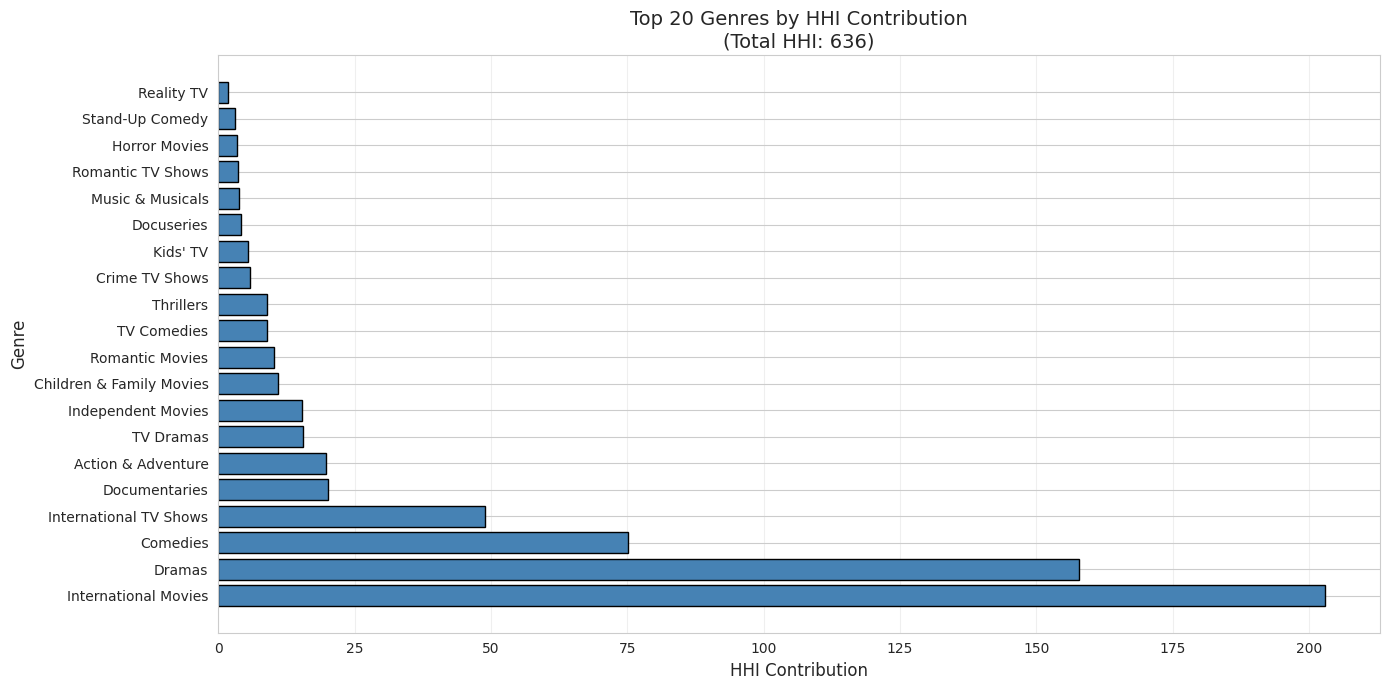


3. Genre Long Tail Analysis (Pareto Principle) - CORRECTED

Pareto Analysis Results:
  - Top 15 genres account for 80% of genre occurrences
  - This represents 35.7% of all genres
  - Remaining 27 genres = 20% of occurrences (long tail)

  ⚙ MODERATE Pareto effect: 35.7% of genres drive 80% of content

THE HEAD (Top 15 genres):
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

THE LONG TAIL (Bottom 10 genres):
listed_in
TV Horror                       75
Cult Movies                     71
Anime Features         

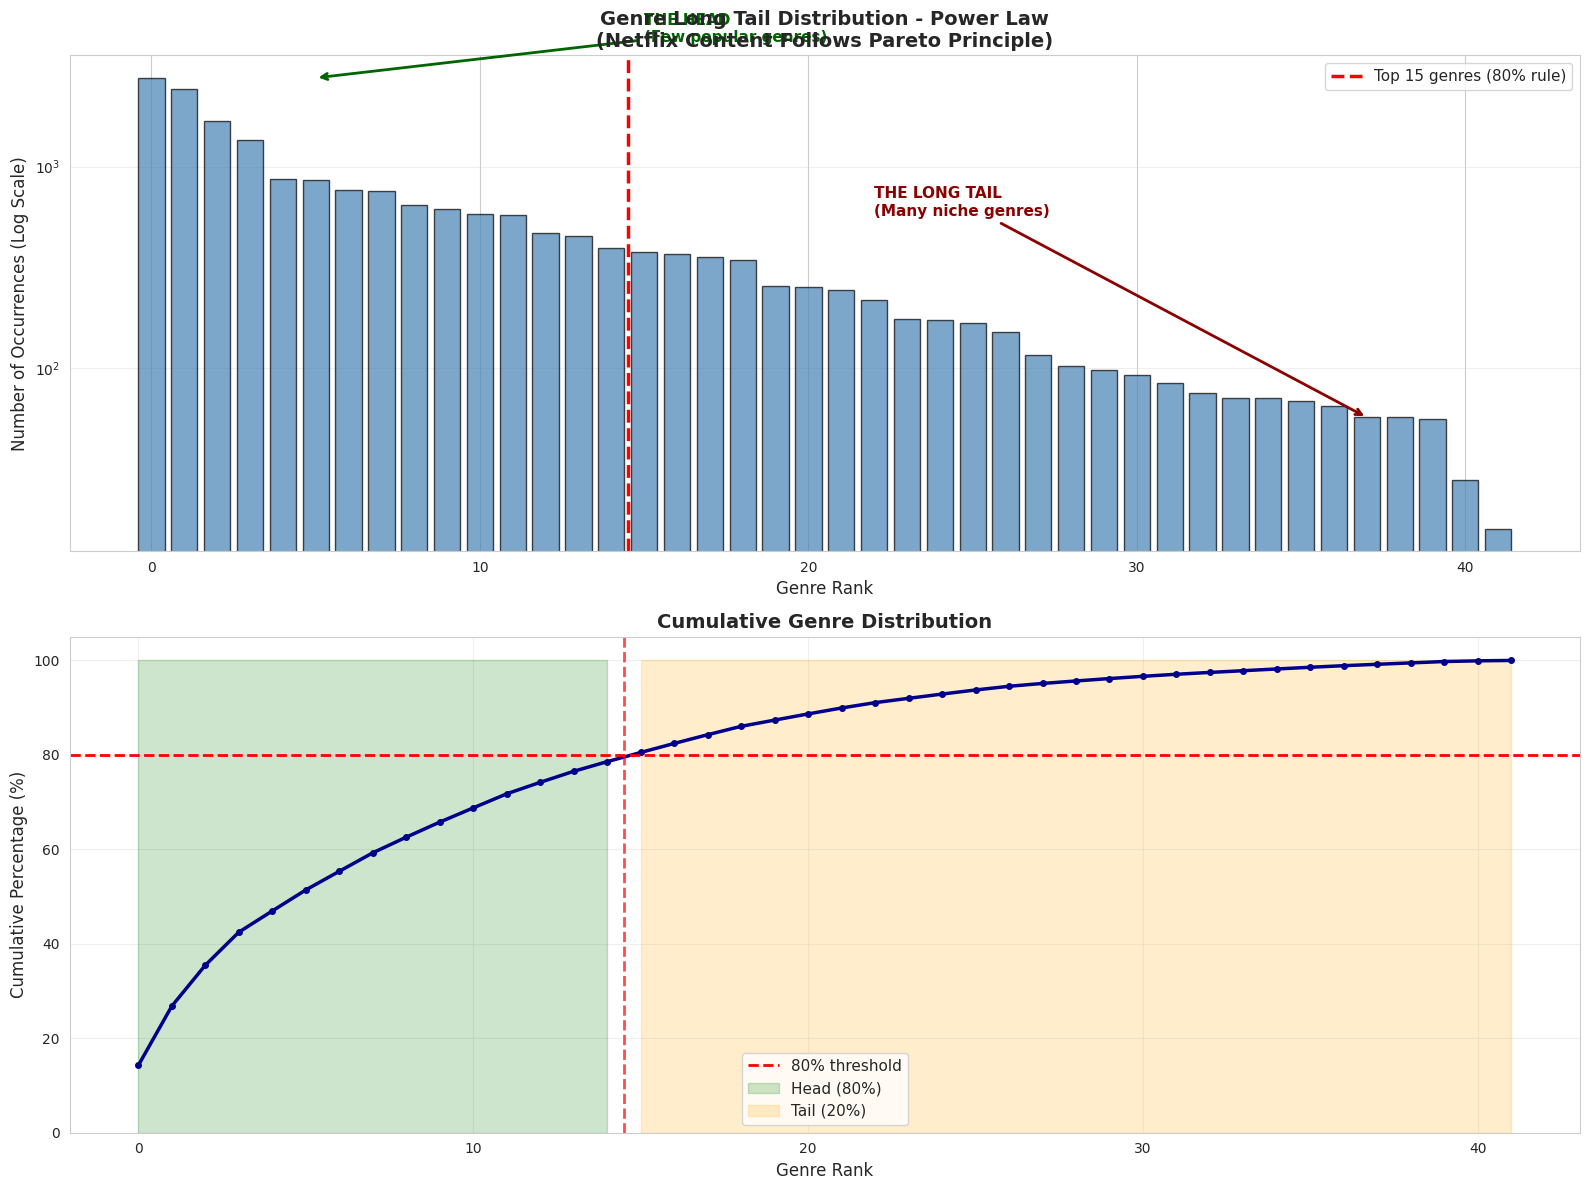


4. Genre Specificity Analysis

Most Specific Genres (Often Stand Alone):
                          total  alone_count   alone_pct
Movies                     57.0         57.0  100.000000
Stand-Up Comedy           343.0        334.0   97.376093
Kids' TV                  451.0        220.0   48.780488
Documentaries             869.0        359.0   41.311853
Reality TV                255.0         95.0   37.254902
Children & Family Movies  641.0        215.0   33.541342
Docuseries                395.0         85.0   21.518987
Horror Movies             357.0         55.0   15.406162
Action & Adventure        859.0        128.0   14.901048
TV Comedies               581.0         69.0   11.876076

Least Specific Genres (Always Combined):
                           total  alone_count  alone_pct
Cult Movies                 71.0          0.0        0.0
Faith & Spirituality        65.0          0.0        0.0
Science & Nature TV         92.0          0.0        0.0
Romantic TV Shows          37

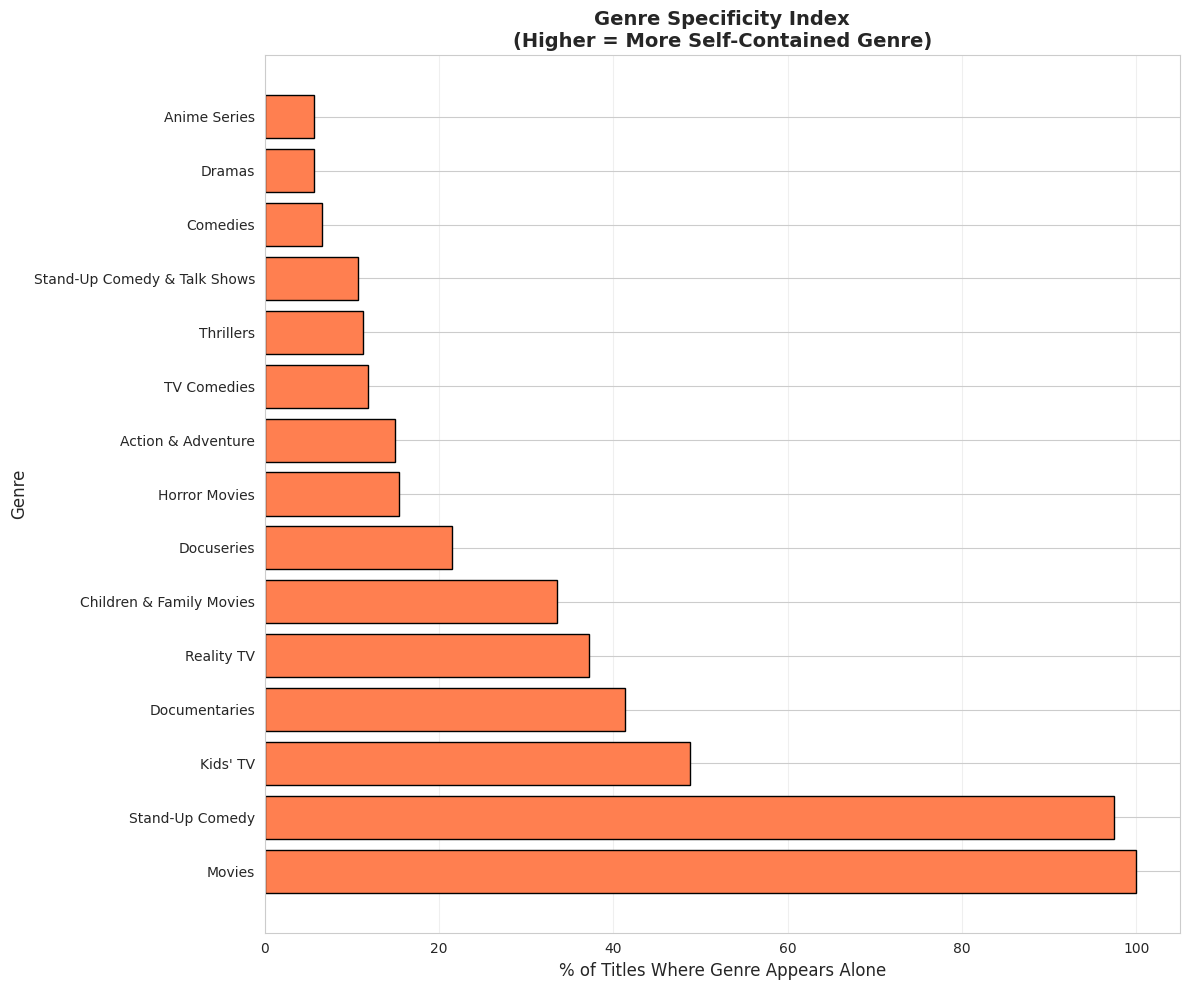


ANALYSIS COMPLETE


In [ ]:
# ============================================
# CORRECTED: Genre Characteristics Analysis
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
import os # Import the os module

# Define the directory for visualizations
viz_dir = '/content/visualizations'
# Create the directory if it doesn't exist
os.makedirs(viz_dir, exist_ok=True)


print("\n" + "="*60)
print("GENRE DISTRIBUTION CHARACTERISTICS (CORRECTED)")
print("="*60 + "\n")

# ============================================
# Step 1: Extract and count individual genres
# ============================================

# Split genres and create individual genre list
all_genres = df_clean['listed_in'].str.split(',').explode()
all_genres = all_genres.str.strip()  # Remove whitespace

# Count occurrences of each genre
genre_counts = all_genres.value_counts()
total_genre_occurrences = genre_counts.sum()

print(f"Total unique genres: {len(genre_counts)}")
print(f"Total genre occurrences: {total_genre_occurrences}")
print(f"\nTop 15 Genres:")
print(genre_counts.head(15))

# ============================================
# 2. CORRECTED: HHI Analysis (Genre Concentration)
# ============================================

print("\n" + "="*60)
print("2. Genre Concentration Analysis (HHI) - CORRECTED")
print("="*60)

# Calculate market share for each genre
genre_shares = genre_counts / total_genre_occurrences

# Calculate HHI
hhi = ((genre_shares ** 2).sum() * 10000)

print(f"\nHHI Score: {hhi:.2f}")
print("\nInterpretation:")
if hhi > 2500:
    print("  ⚠ HIGH concentration - Over-reliance on few genres")
    print("  Risk: Vulnerable to shifts in viewer preferences")
elif hhi > 1500:
    print("  ⚙ MODERATE concentration - Relatively balanced")
    print("  Strategy: Focus on core genres with some diversification")
else:
    print("  ✓ LOW concentration - Well-diversified portfolio")
    print("  Strategy: Serving diverse audience segments effectively")

# Additional HHI metrics
print(f"\nAdditional Metrics:")
print(f"  - Equivalent number of equal-sized genres: {(10000/hhi):.1f}")
print(f"  - Top genre share: {genre_shares.iloc[0]*100:.1f}%")
print(f"  - Top 3 genres combined: {genre_shares.head(3).sum()*100:.1f}%")

# Visualize HHI contribution by genre
fig, ax = plt.subplots(figsize=(14, 7))
hhi_contribution = (genre_shares ** 2) * 10000
top_genres_hhi = hhi_contribution.head(20)

ax.barh(range(len(top_genres_hhi)), top_genres_hhi.values, color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top_genres_hhi)))
ax.set_yticklabels(top_genres_hhi.index)
ax.set_xlabel('HHI Contribution', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title(f'Top 20 Genres by HHI Contribution\n(Total HHI: {hhi:.0f})', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'genre_hhi_corrected.png'), dpi=300, bbox_inches='tight') # Updated save path
plt.show()

# ============================================
# 3. CORRECTED: Long Tail Analysis (Pareto Principle)
# ============================================

print("\n" + "="*60)
print("3. Genre Long Tail Analysis (Pareto Principle) - CORRECTED")
print("="*60)

# Sort genres by frequency
genre_sorted = genre_counts.sort_values(ascending=False)

# Calculate cumulative percentage
genre_cumsum_pct = (genre_sorted.cumsum() / genre_sorted.sum() * 100)

# Find how many genres account for 80% of content
top_genres_for_80 = (genre_cumsum_pct <= 80).sum()
pct_genres_for_80 = (top_genres_for_80 / len(genre_sorted)) * 100

print(f"\nPareto Analysis Results:")
print(f"  - Top {top_genres_for_80} genres account for 80% of genre occurrences")
print(f"  - This represents {pct_genres_for_80:.1f}% of all genres")
print(f"  - Remaining {len(genre_sorted) - top_genres_for_80} genres = 20% of occurrences (long tail)")

# Check if it follows classic 80/20 rule
if pct_genres_for_80 < 25:
    print(f"\n  ✓ STRONG Pareto effect: {pct_genres_for_80:.1f}% of genres drive 80% of content")
elif pct_genres_for_80 < 40:
    print(f"\n  ⚙ MODERATE Pareto effect: {pct_genres_for_80:.1f}% of genres drive 80% of content")
else:
    print(f"\n  ⚠ WEAK Pareto effect: {pct_genres_for_80:.1f}% of genres needed for 80% of content")
    print("  → Indicates strong diversification strategy")

# Show the head and tail
print(f"\nTHE HEAD (Top {top_genres_for_80} genres):")
print(genre_sorted.head(top_genres_for_80))

print(f"\nTHE LONG TAIL (Bottom 10 genres):")
print(genre_sorted.tail(10))

# ============================================
# Visualize Long Tail Distribution
# ============================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Top subplot: Log-scale bar chart
ax1.bar(range(len(genre_sorted)), genre_sorted.values, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=top_genres_for_80-0.5, color='red', linestyle='--', linewidth=2.5,
            label=f'Top {top_genres_for_80} genres (80% rule)')
ax1.set_xlabel('Genre Rank', fontsize=12)
ax1.set_ylabel('Number of Occurrences (Log Scale)', fontsize=12)
ax1.set_title('Genre Long Tail Distribution - Power Law\n(Netflix Content Follows Pareto Principle)',
              fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# Add annotations for head and tail
ax1.annotate('THE HEAD\n(Few popular genres)', xy=(5, genre_sorted.iloc[0]),
             xytext=(15, genre_sorted.iloc[0]*1.5),
             arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2),
             fontsize=11, color='darkgreen', fontweight='bold')

ax1.annotate('THE LONG TAIL\n(Many niche genres)', xy=(len(genre_sorted)-5, genre_sorted.iloc[-5]),
             xytext=(len(genre_sorted)-20, genre_sorted.iloc[-5]*10),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=2),
             fontsize=11, color='darkred', fontweight='bold')

# Bottom subplot: Cumulative percentage
ax2.plot(range(len(genre_cumsum_pct)), genre_cumsum_pct.values,
         color='darkblue', linewidth=2.5, marker='o', markersize=4)
ax2.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% threshold')
ax2.axvline(x=top_genres_for_80-0.5, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.fill_between(range(top_genres_for_80), 0, 100, alpha=0.2, color='green', label='Head (80%)')
ax2.fill_between(range(top_genres_for_80, len(genre_sorted)), 0, 100, alpha=0.2, color='orange', label='Tail (20%)')
ax2.set_xlabel('Genre Rank', fontsize=12)
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax2.set_title('Cumulative Genre Distribution', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'genre_long_tail_corrected.png'), dpi=300, bbox_inches='tight') # Updated save path
plt.show()

# ============================================
# 4. Genre Specificity Index (Keep Original - This was correct!)
# ============================================

print("\n" + "="*60)
print("4. Genre Specificity Analysis")
print("="*60)

# Create binary matrix for genres
mlb = MultiLabelBinarizer()
genre_lists = df_clean['listed_in'].str.split(',').apply(lambda x: [i.strip() for i in x])
genre_matrix = pd.DataFrame(mlb.fit_transform(genre_lists),
                            columns=mlb.classes_,
                            index=df_clean.index)

# Add genre count to main dataframe
df_clean['genre_count'] = genre_matrix.sum(axis=1)

# Calculate specificity for each genre
genre_specificity = {}

for genre in mlb.classes_:
    genre_titles = df_clean[genre_matrix[genre] == 1]
    alone_count = (genre_titles['genre_count'] == 1).sum()
    total_count = len(genre_titles)
    specificity = alone_count / total_count * 100 if total_count > 0 else 0
    genre_specificity[genre] = {
        'total': total_count,
        'alone_count': alone_count,
        'alone_pct': specificity
    }

specificity_df = pd.DataFrame(genre_specificity).T
specificity_df = specificity_df[specificity_df['total'] >= 30]  # Filter small genres
specificity_df = specificity_df.sort_values('alone_pct', ascending=False)

print("\nMost Specific Genres (Often Stand Alone):")
print(specificity_df.head(10).to_string())

print("\nLeast Specific Genres (Always Combined):")
print(specificity_df.tail(10).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(12, 10))
top_specific = specificity_df.head(15)
ax.barh(range(len(top_specific)), top_specific['alone_pct'], color='coral', edgecolor='black')
ax.set_yticks(range(len(top_specific)))
ax.set_yticklabels(top_specific.index)
ax.set_xlabel('% of Titles Where Genre Appears Alone', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title('Genre Specificity Index\n(Higher = More Self-Contained Genre)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'genre_specificity.png'), dpi=300, bbox_inches='tight') # Updated save path
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

Temporal Trend Analysis



TEMPORAL PATTERN ANALYSIS

1. Monthly Seasonality Pattern:


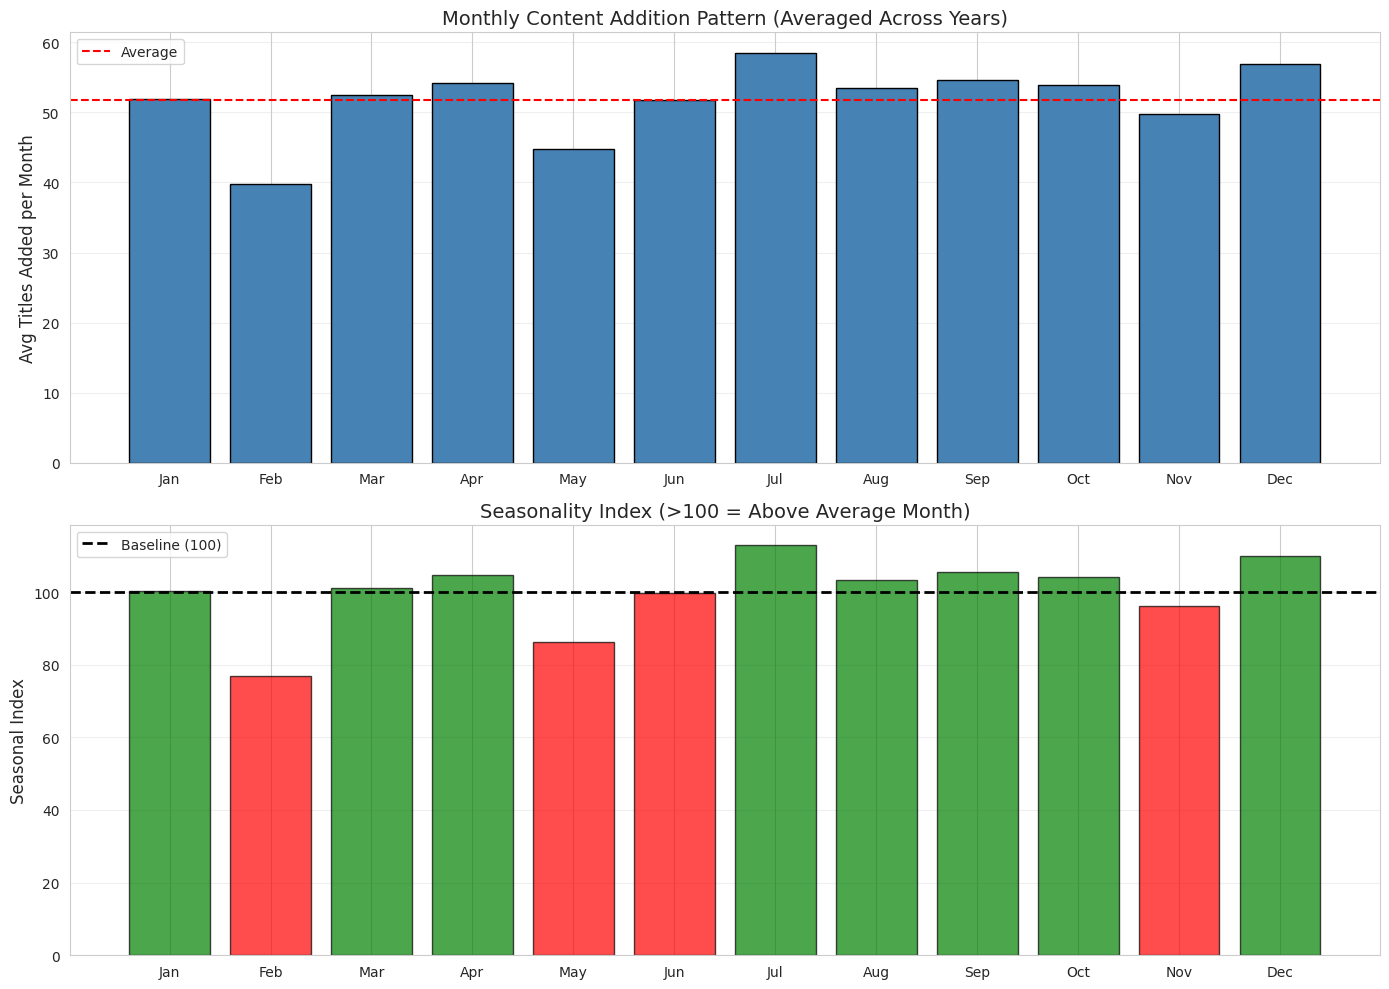


✓ Peak month: Jul (Index: 113)
✓ Slowest month: Feb (Index: 77)

2. Netflix Growth Phases:


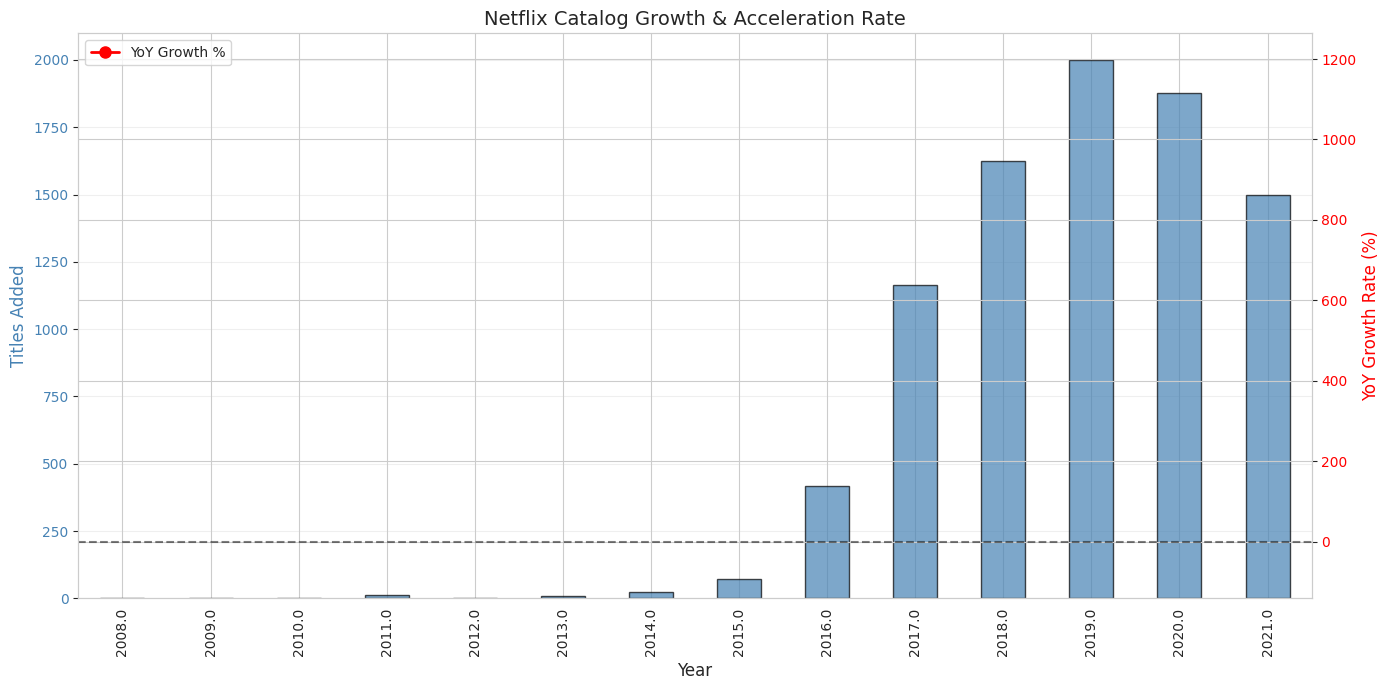


✓ Peak growth year: 2011.0 (1200.0% growth)
⚠ First slowdown: 2010.0 (-50.0%)

3. Content Addition Velocity:


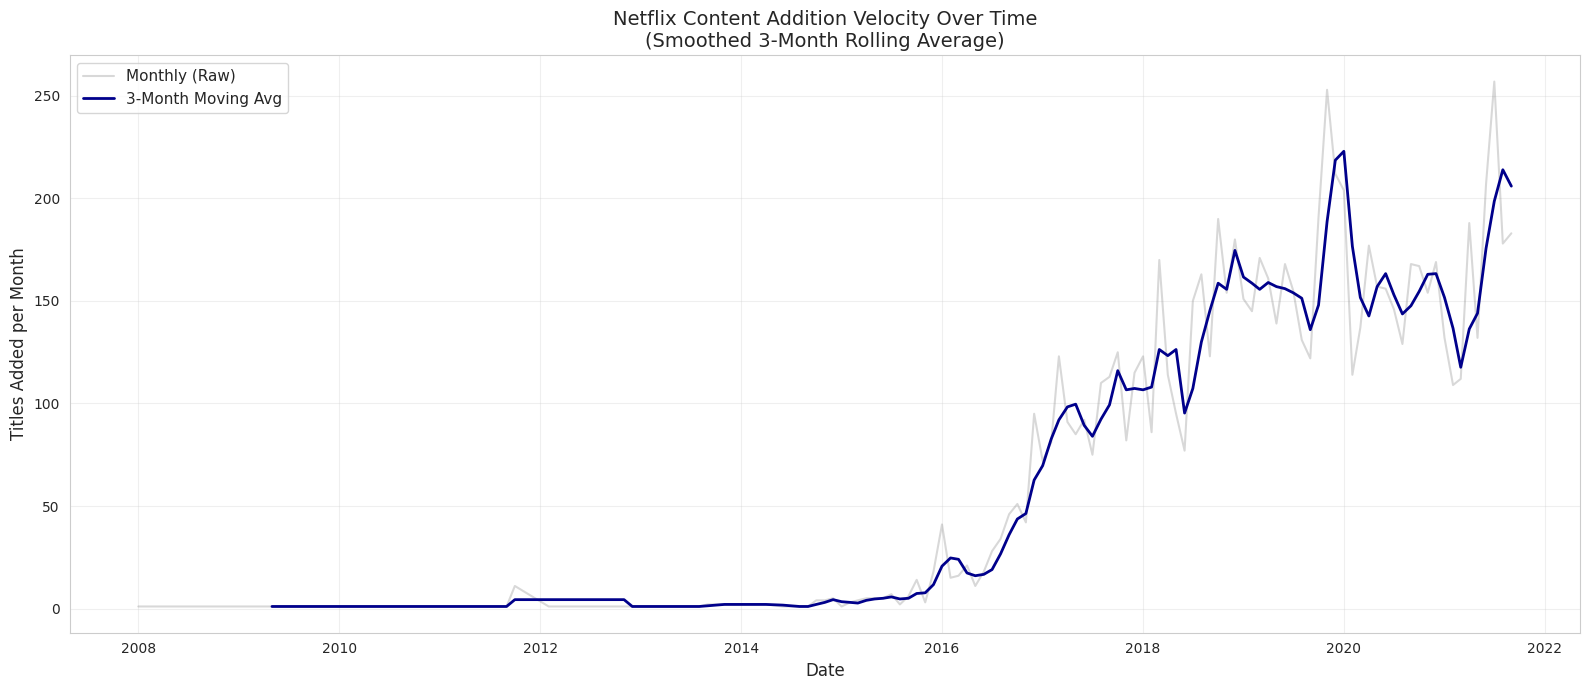


Early period velocity (first 12 months): 1.8 titles/month
Recent velocity (last 12 months): 165.7 titles/month
Change: +8936.4%


In [ ]:
# ============================================
# DEEP DIVE: Temporal Trend Analysis
# ============================================

import os # Import the os module

# Define the directory for visualizations
viz_dir = '/content/visualizations'
# Create the directory if it doesn't exist
os.makedirs(viz_dir, exist_ok=True)

print("\n" + "="*60)
print("TEMPORAL PATTERN ANALYSIS")
print("="*60 + "\n")

# 1. Seasonality analysis
print("1. Monthly Seasonality Pattern:")
df_valid_dates = df_clean[df_clean['date_added'].notna()]

monthly_additions = df_valid_dates.groupby('month_added').size()
monthly_avg = monthly_additions / df_valid_dates['year_added'].nunique()

# Seasonal index (100 = average month)
seasonal_index = (monthly_avg / monthly_avg.mean()) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Monthly pattern
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.bar(range(1, 13), monthly_avg.values, color='steelblue', edgecolor='black')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_ylabel('Avg Titles Added per Month', fontsize=12)
ax1.set_title('Monthly Content Addition Pattern (Averaged Across Years)', fontsize=14)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=monthly_avg.mean(), color='red', linestyle='--', label='Average')
ax1.legend()

# Seasonal index
colors = ['green' if x > 100 else 'red' for x in seasonal_index.values]
ax2.bar(range(1, 13), seasonal_index.values, color=colors, edgecolor='black', alpha=0.7)
ax2.axhline(y=100, color='black', linestyle='--', linewidth=2, label='Baseline (100)')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names)
ax2.set_ylabel('Seasonal Index', fontsize=12)
ax2.set_title('Seasonality Index (>100 = Above Average Month)', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'monthly_seasonality.png'), dpi=300, bbox_inches='tight') # Updated save path
plt.show()

peak_month = month_names[int(seasonal_index.idxmax()) - 1]
low_month = month_names[int(seasonal_index.idxmin()) - 1]
print(f"\n✓ Peak month: {peak_month} (Index: {seasonal_index.max():.0f})")
print(f"✓ Slowest month: {low_month} (Index: {seasonal_index.min():.0f})")

# 2. Growth phase identification
print("\n2. Netflix Growth Phases:")
yearly_additions = df_valid_dates.groupby('year_added').size()
yearly_growth_rate = yearly_additions.pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 7))

# Bar chart
yearly_additions.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.7)

# Growth rate overlay
ax2 = ax.twinx()
yearly_growth_rate.plot(kind='line', ax=ax2, color='red', marker='o',
                        linewidth=2, markersize=8, label='YoY Growth %')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Titles Added', fontsize=12, color='steelblue')
ax2.set_ylabel('YoY Growth Rate (%)', fontsize=12, color='red')
ax.set_title('Netflix Catalog Growth & Acceleration Rate', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'growth_phases.png'), dpi=300, bbox_inches='tight') # Updated save path
plt.show()

# Identify inflection points
peak_growth_year = yearly_growth_rate.idxmax()
slowdown_year = yearly_growth_rate[yearly_growth_rate < 0].index[0] if any(yearly_growth_rate < 0) else None

print(f"\n✓ Peak growth year: {peak_growth_year} ({yearly_growth_rate.max():.1f}% growth)")
if slowdown_year:
    print(f"⚠ First slowdown: {slowdown_year} ({yearly_growth_rate[slowdown_year]:.1f}%)")

# 3. Content velocity (titles per day)
print("\n3. Content Addition Velocity:")
df_valid_dates['year_month'] = df_valid_dates['date_added'].dt.to_period('M')
monthly_velocity = df_valid_dates.groupby('year_month').size()

# Rolling average (3-month smoothing)
velocity_smooth = monthly_velocity.rolling(window=3).mean()

plt.figure(figsize=(16, 7))
plt.plot(monthly_velocity.index.to_timestamp(), monthly_velocity.values,
         alpha=0.3, color='gray', label='Monthly (Raw)')
plt.plot(velocity_smooth.index.to_timestamp(), velocity_smooth.values,
         color='darkblue', linewidth=2, label='3-Month Moving Avg')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Titles Added per Month', fontsize=12)
plt.title('Netflix Content Addition Velocity Over Time\n(Smoothed 3-Month Rolling Average)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'content_velocity.png'), dpi=300, bbox_inches='tight') # Updated save path
plt.show()

recent_velocity = monthly_velocity.iloc[-12:].mean()
early_velocity = monthly_velocity.iloc[:12].mean()
print(f"\nEarly period velocity (first 12 months): {early_velocity:.1f} titles/month")
print(f"Recent velocity (last 12 months): {recent_velocity:.1f} titles/month")
print(f"Change: {(recent_velocity - early_velocity) / early_velocity * 100:+.1f}%")


CONTENT TYPE DEEP DIVE

1. Content Type Strategic Shift:


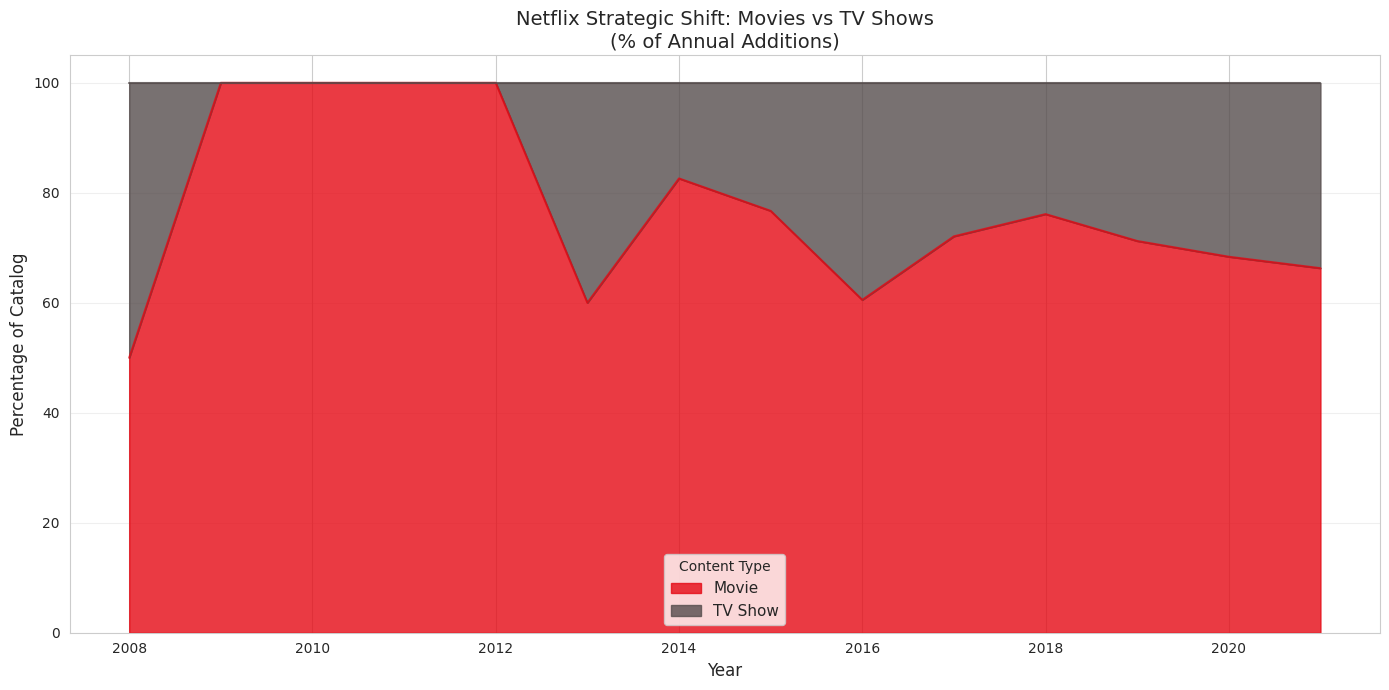


✓ Movies/TV parity reached: ~2008.0
Current split (2021): Movies 66.3% | TV 33.7%

2. Genre Preferences by Content Type:


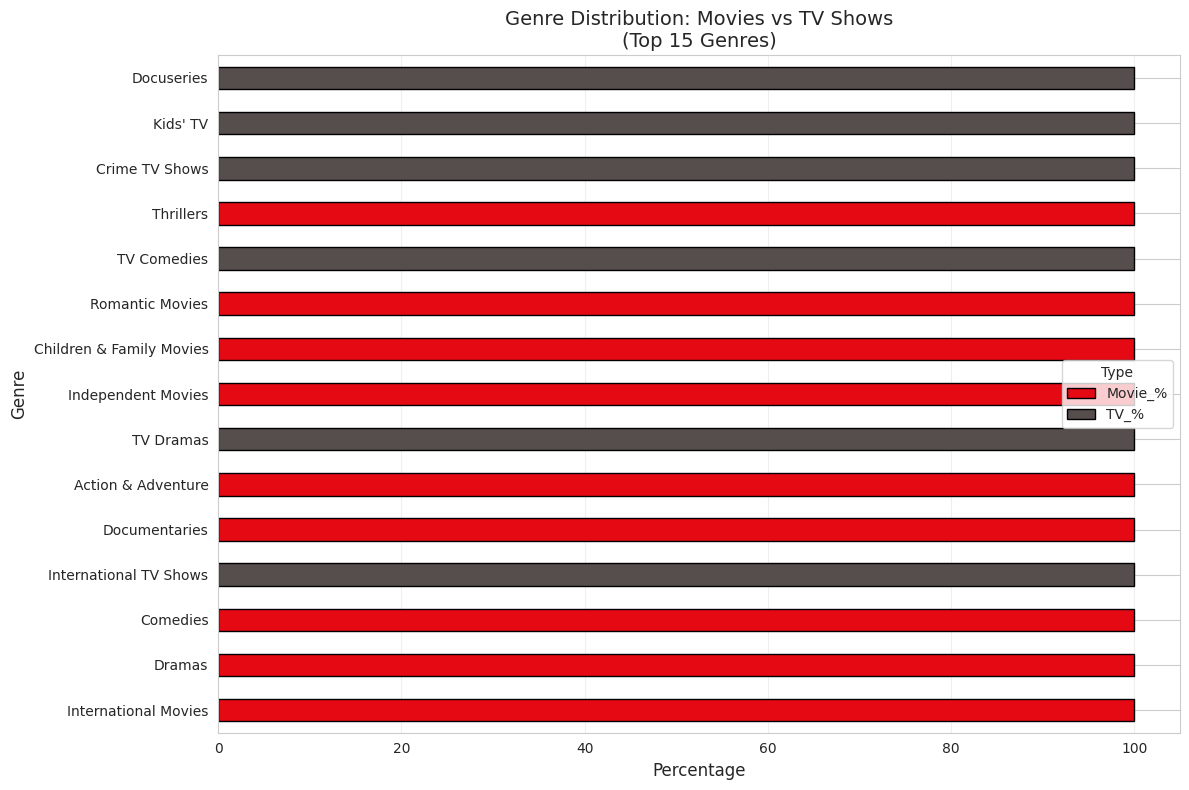


Movie-Heavy Genres:
               Genre  Movie_%
International Movies    100.0
              Dramas    100.0
            Comedies    100.0
       Documentaries    100.0
  Action & Adventure    100.0

TV-Heavy Genres:
                 Genre  TV_%
International TV Shows 100.0
             TV Dramas 100.0
           TV Comedies 100.0
        Crime TV Shows 100.0
              Kids' TV 100.0


In [ ]:
# ============================================
# DEEP DIVE: Content Type Strategic Analysis
# ============================================

import os # Import the os module

# Define the directory for visualizations
viz_dir = '/content/visualizations'
# Create the directory if it doesn't exist
os.makedirs(viz_dir, exist_ok=True)

print("\n" + "="*60)
print("CONTENT TYPE DEEP DIVE")
print("="*60 + "\n")

# 1. Movie vs TV Show evolution
print("1. Content Type Strategic Shift:")
type_by_year = pd.crosstab(df_clean['year_added'], df_clean['type'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 7))
type_by_year.plot(kind='area', stacked=True, ax=ax, color=['#E50914', '#564d4d'], alpha=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percentage of Catalog', fontsize=12)
ax.set_title('Netflix Strategic Shift: Movies vs TV Shows\n(% of Annual Additions)', fontsize=14)
ax.legend(title='Content Type', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'content_type_evolution.png'), dpi=300, bbox_inches='tight') # Updated save path
plt.show()

# Calculate crossover point
movie_pct = type_by_year['Movie']
tv_pct = type_by_year['TV Show']
crossover_years = type_by_year[(movie_pct - tv_pct).abs() < 5].index.tolist()

if crossover_years:
    print(f"\n✓ Movies/TV parity reached: ~{crossover_years[0]}")
print(f"Current split (2021): Movies {movie_pct.iloc[-1]:.1f}% | TV {tv_pct.iloc[-1]:.1f}%")

# 2. Type-Genre matrix
print("\n2. Genre Preferences by Content Type:")
type_genre_matrix = []

# Corrected: Use .head(15).index.tolist() to get top genres from the Series
for genre in genre_counts.head(15).index.tolist():
    genre_mask = genre_matrix[genre] == 1
    movie_pct = df_clean[genre_mask & (df_clean['type'] == 'Movie')].shape[0] / df_clean[genre_mask].shape[0] * 100
    tv_pct = 100 - movie_pct
    type_genre_matrix.append({
        'Genre': genre,
        'Movie_%': movie_pct,
        'TV_%': tv_pct,
        'Total': genre_mask.sum()
    })

type_genre_df = pd.DataFrame(type_genre_matrix)

fig, ax = plt.subplots(figsize=(12, 8))
type_genre_df.set_index('Genre')[['Movie_%', 'TV_%']].plot(
    kind='barh', stacked=True, ax=ax, color=['#E50914', '#564d4d'], edgecolor='black'
)
ax.set_xlabel('Percentage', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title('Genre Distribution: Movies vs TV Shows\n(Top 15 Genres)', fontsize=14)
ax.legend(title='Type', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'type_genre_matrix.png'), dpi=300, bbox_inches='tight') # Updated save path
plt.show()

# Identify movie-heavy and TV-heavy genres
movie_heavy = type_genre_df.nlargest(5, 'Movie_%')[['Genre', 'Movie_%']]
tv_heavy = type_genre_df.nlargest(5, 'TV_%')[['Genre', 'TV_%']]

print("\nMovie-Heavy Genres:")
print(movie_heavy.to_string(index=False))
print("\nTV-Heavy Genres:")
print(tv_heavy.to_string(index=False))


RATING & AUDIENCE TARGETING ANALYSIS

1. Audience Demographic Portfolio:
demographic
Mature    46.463041
Teen      30.089701
Family    15.555808
Kids       7.811968
Name: count, dtype: float64

Total titles analyzed: 8807


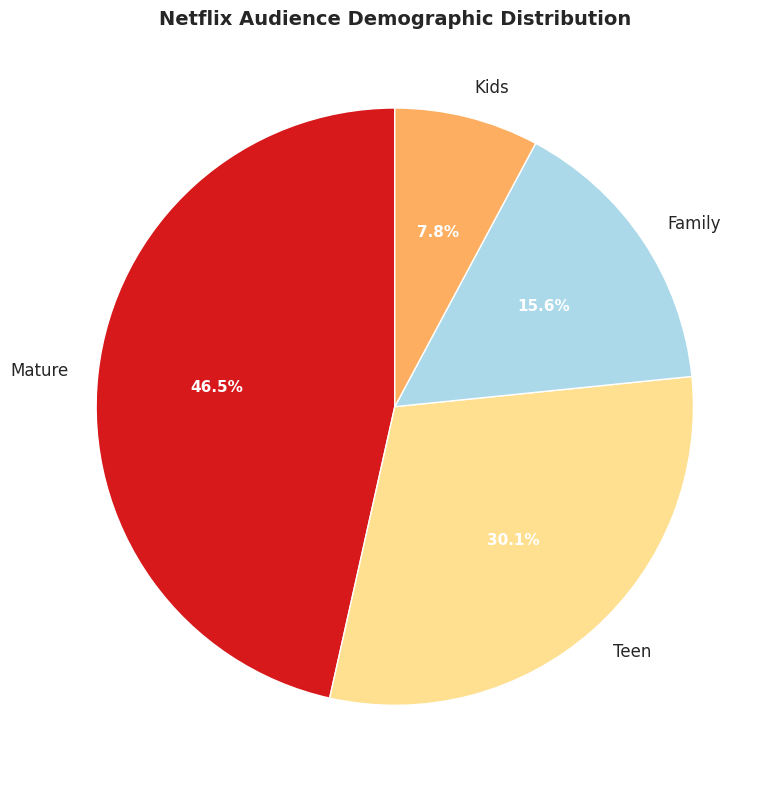


PORTFOLIO INSIGHTS

✓ Mature Content (17+): 46.5%
  → Netflix positions itself as premium, adult-focused platform

✓ Family Content (PG/TV-PG): 15.6%
  → Secondary audience segment, multi-household appeal

✓ Kids Content (TV-Y to G): 7.8%
  → Minimal offering; Netflix outsources to partners

✓ All-Ages Capable Content: 23.4%
  → Content watchable by households with children

⚠ Strategic Positioning: Adult-Centric
   Rationale: Premium pricing, ad-tier revenue optimization

2. Content Maturity Trend:


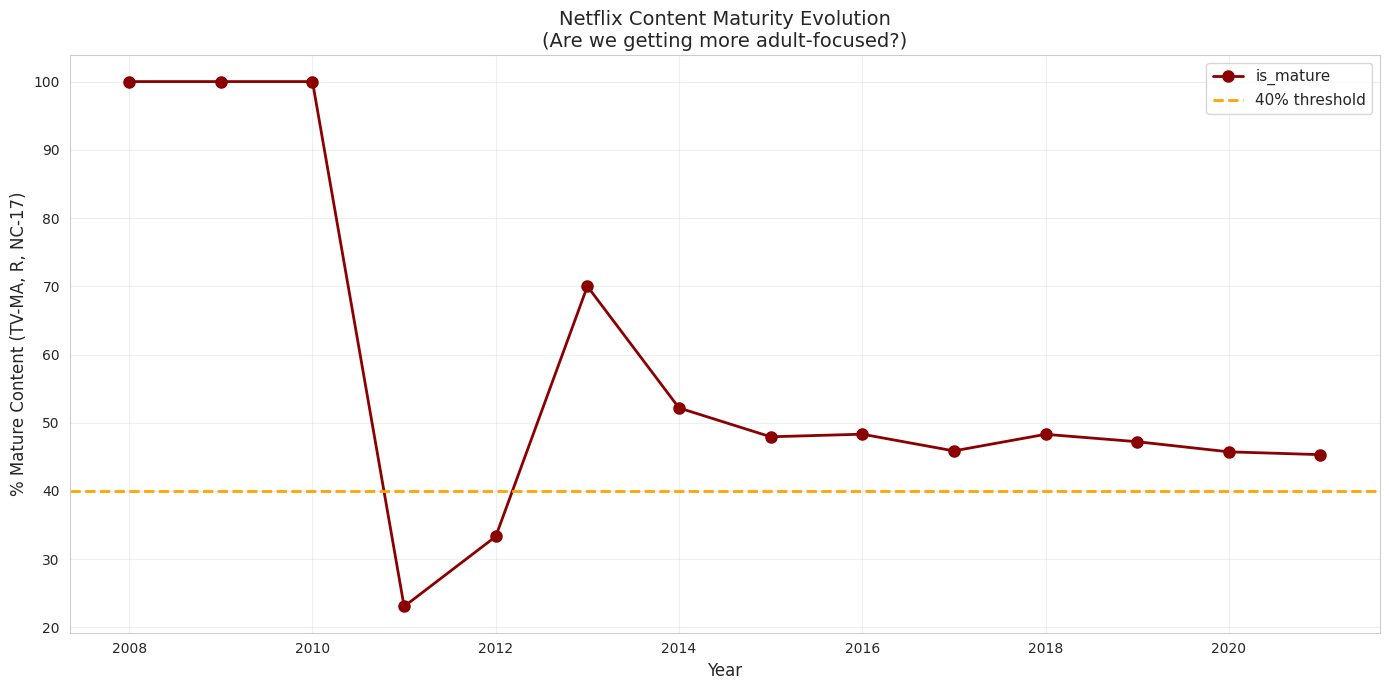

In [ ]:
print("\n" + "="*60)
print("RATING & AUDIENCE TARGETING ANALYSIS")
print("="*60 + "\n")

# 1. Demographic segmentation
print("1. Audience Demographic Portfolio:")

# Categorize ratings into demographic segments
demographic_map = {
    'Kids': ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G'],
    'Family': ['TV-G', 'PG', 'TV-PG'],
    'Teen': ['PG-13', 'TV-14'],
    'Mature': ['R', 'NC-17', 'TV-MA', 'NR', 'UR']
}

df_clean['demographic'] = df_clean['rating'].map(
    {rating: demo for demo, ratings in demographic_map.items() for rating in ratings}
)

demo_dist = df_clean['demographic'].value_counts()
demo_pct = (demo_dist / len(df_clean) * 100).sort_values(ascending=False)

print(demo_pct)
print(f"\nTotal titles analyzed: {len(df_clean)}")

# Visualization - Single pie chart
fig, ax = plt.subplots(figsize=(10, 8))

colors_demo = ['#d7191c', '#fee090', '#abd9e9', '#fdae61']
wedges, texts, autotexts = ax.pie(demo_pct.values, labels=demo_pct.index,
                                    autopct='%1.1f%%', startangle=90,
                                    colors=colors_demo, textprops={'fontsize': 12})

# Enhance text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax.set_title('Netflix Audience Demographic Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/visualizations/demographic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Strategic insight - Actual portfolio analysis
print("\n" + "="*60)
print("PORTFOLIO INSIGHTS")
print("="*60)

mature_pct = demo_pct.get('Mature', 0)
family_pct = demo_pct.get('Family', 0)
kids_pct = demo_pct.get('Kids', 0)

print(f"\n✓ Mature Content (17+): {mature_pct:.1f}%")
print(f"  → Netflix positions itself as premium, adult-focused platform")

print(f"\n✓ Family Content (PG/TV-PG): {family_pct:.1f}%")
print(f"  → Secondary audience segment, multi-household appeal")

print(f"\n✓ Kids Content (TV-Y to G): {kids_pct:.1f}%")
print(f"  → Minimal offering; Netflix outsources to partners")

# Audience span calculation
all_ages_capable = (kids_pct + family_pct)
print(f"\n✓ All-Ages Capable Content: {all_ages_capable:.1f}%")
print(f"  → Content watchable by households with children")

# Strategic positioning
if mature_pct > 45:
    print(f"\n⚠ Strategic Positioning: Adult-Centric")
    print(f"   Rationale: Premium pricing, ad-tier revenue optimization")
elif mature_pct < 30:
    print(f"\n⚠ Strategic Positioning: Family-Balanced")
    print(f"   Rationale: Broad household appeal, retention focus")
else:
    print(f"\n⚠ Strategic Positioning: Mixed Appeal")
    print(f"   Rationale: Balance between premium & accessibility")

# 2. Rating maturity trend over time
print("\n2. Content Maturity Trend:")
df_clean['is_mature'] = df_clean['demographic'] == 'Mature'
maturity_trend = df_clean.groupby('year_added')['is_mature'].mean() * 100

plt.figure(figsize=(14, 7))
maturity_trend.plot(kind='line', marker='o', linewidth=2, markersize=8, color='darkred')
plt.axhline(y=40, color='orange', linestyle='--', linewidth=2, label='40% threshold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('% Mature Content (TV-MA, R, NC-17)', fontsize=12)
plt.title('Netflix Content Maturity Evolution\n(Are we getting more adult-focused?)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('/content/visualizations/maturity_trend.png', dpi=300, bbox_inches='tight')
plt.show()

if maturity_trend.iloc[-1] > maturity_trend.iloc[0]:
    change = maturity_trend.iloc[-1] - maturity_trend.iloc[0]
    print(f"⚠ Mature content increased by {change:.1f}% since {maturity_trend.index[0]}")

CROSS GENRE ANALYSIS


In [ ]:
#creating genre matrix

from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

#create a set of unique genres from all_genres
unique_genres = sorted(list(set(all_genres)))

mlb = MultiLabelBinarizer(classes=unique_genres)
genre_matrix = pd.DataFrame(
    mlb.fit_transform(df_clean['listed_in'].str.split(',').apply(lambda x: [i.strip() for i in x])),
    columns=mlb.classes_,
    index=df_clean.index
)

print("Genre matrix shape:", genre_matrix.shape)
display(genre_matrix.head())

Genre matrix shape: (8807, 42)


,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
#genre co occurrence matrix

import numpy as np

# Co-occurrence counts (number of titles sharing both genres)
cooc = pd.DataFrame(
    np.dot(genre_matrix.T.values, genre_matrix.values),
    index=mlb.classes_,
    columns=mlb.classes_
)

# Zero out diagonal (self co-occurrence not needed)
np.fill_diagonal(cooc.values, 0)

cooc.head()


,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
Action & Adventure,0,50,0,0,26,0,31,183,0,20,...,0,0,0,0,0,0,0,0,0,9
Anime Features,50,0,0,0,14,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Anime Series,0,0,0,0,0,0,0,0,16,0,...,1,0,0,6,0,0,0,8,15,0
British TV Shows,0,0,0,0,0,6,0,0,50,0,...,5,39,24,1,0,1,0,2,0,0
Children & Family Movies,26,14,0,0,0,0,9,270,0,2,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#compute pointwise mutual information
#Higher PMI -  genres that co-occur more than expected by chance (majorly occur together)

import itertools
import numpy as np

N = len(df_clean) # Use the cleaned dataframe length for total number of titles
# genre_counts is already computed and available from the previous cell's execution context as a dictionary

def pmi(a, b, N, genre_counts, cooc):
    """Calculates Pointwise Mutual Information for two genres."""
    pa = genre_counts.get(a, 0) / N
    pb = genre_counts.get(b, 0) / N
    pab = cooc.loc[a, b] / N

    # Avoid division by zero or log of zero
    if pa == 0 or pb == 0 or pab == 0:
        return np.nan
    return np.log2(pab / (pa * pb))

# Compute pairwise PMI using the cooc matrix's index and columns (unique genres)
pmi_values = []
# Iterate over unique genre combinations from the cooc matrix
for g1, g2 in itertools.combinations(cooc.index, 2):
    cooccurrence_count = cooc.loc[g1, g2]
    if cooccurrence_count > 0: # Only compute PMI for genres that co-occur at least once
        pmi_score = pmi(g1, g2, N, genre_counts, cooc)
        pmi_values.append((g1, g2, cooccurrence_count, pmi_score))

pmi_df = pd.DataFrame(pmi_values, columns=['Genre_1', 'Genre_2', 'Cooccurrence', 'PMI'])
pmi_df = pmi_df.dropna().sort_values('PMI', ascending=False)

print("Top 10 Genre Pairs by PMI:")
display(pmi_df.head(10))

print("\nBottom 10 Genre Pairs by PMI:")
display(pmi_df.tail(10))

Top 10 Genre Pairs by PMI:


,Genre_1,Genre_2,Cooccurrence,PMI
274,TV Horror,TV Mysteries,29,5.118887
260,TV Action & Adventure,TV Sci-Fi & Fantasy,41,4.677352
276,TV Horror,TV Thrillers,12,4.627689
135,Docuseries,Science & Nature TV,88,4.414596
71,Classic & Cult TV,TV Sci-Fi & Fantasy,4,3.904763
73,Classic Movies,Cult Movies,13,3.797147
66,Classic & Cult TV,TV Action & Adventure,7,3.712118
278,TV Mysteries,TV Sci-Fi & Fantasy,12,3.682370
279,TV Mysteries,TV Thrillers,8,3.656835
69,Classic & Cult TV,TV Horror,3,3.653224



Bottom 10 Genre Pairs by PMI:


,Genre_1,Genre_2,Cooccurrence,PMI
102,Crime TV Shows,Reality TV,1,-3.766435
97,Comedies,Thrillers,8,-3.777076
131,Documentaries,Stand-Up Comedy,2,-4.080842
126,Documentaries,Horror Movies,2,-4.138558
133,Docuseries,Kids' TV,1,-4.338258
227,Reality TV,TV Dramas,1,-4.465458
145,Dramas,Horror Movies,3,-5.035341
86,Comedies,Documentaries,3,-5.782899
180,International TV Shows,Kids' TV,1,-6.112361
124,Documentaries,Dramas,3,-6.318773


In [ ]:
#visualizing genre co occurrence
import plotly.express as px

top_genres = genre_matrix.sum().sort_values(ascending=False).head(20).index

# Create the heatmap using Plotly Express
fig = px.imshow(
    cooc.loc[top_genres, top_genres],
    x=top_genres,
    y=top_genres,
    color_continuous_scale='Hot', # Changed color scale to 'Hot' for black to red gradient
    title='Genre Co-occurrence Heatmap (Top 20 Genres)'
)

# Improve layout and add hover information
fig.update_layout(
    xaxis_title="Genre 2",
    yaxis_title="Genre 1",
    xaxis={'side': 'bottom'},
    title_x=0.5,
    paper_bgcolor='black',
    plot_bgcolor='black',
)

fig.update_traces(hovertemplate='Genre 1: %{y}<br>Genre 2: %{x}<br>Co-occurrence: %{z}<extra></extra>')

# Change text color to white
fig.update_layout(
    font=dict(color='white')
)

# Show plot
fig.show()

fig.write_html("genre_cooccurrence_heatmap", include_plotlyjs="cdn")

In [ ]:
#network graph of genre relationships

import networkx as nx
import plotly.graph_objects as go
import numpy as np

# Filter by co-occurrence count & PMI threshold
min_count = 10      # tune based on dataset size
min_pmi = 1.2

G = nx.Graph()
for _, row in pmi_df.iterrows():
    if row['Cooccurrence'] >= min_count and row['PMI'] >= min_pmi:
        G.add_edge(row['Genre_1'], row['Genre_2'], weight=row['PMI'])

# Get positions for the nodes using a layout algorithm (e.g., spring layout)
pos = nx.spring_layout(G, k=0.4, seed=42)

# Create edges
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None) # Add None to break the line
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='grey'), # Set line color to grey
    hoverinfo='none',
    mode='lines')

# Create nodes
node_x = []
node_y = []
node_text = []
node_size = [] # To scale node size by degree or volume
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)
    # Example: size by degree or genre volume (need to compute/fetch genre_counts)
    node_size.append(G.degree[node] * 20) # Scale by degree for now

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    hoverinfo='text',
    text=node_text,
    textposition="top center",
    marker=dict(
        showscale=False,
        colorscale='Reds', # Use Reds for red circles
        reversescale=False,
        color='red', # Set node color to red
        size=node_size,
        line_width=1))

# Create figure
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='Genre Co-occurrence Network (Filtered by PMI & Count)',
                titlefont_size=16,
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                annotations=[ dict(
                    text="Network graph showing genres that frequently co-occur and have high Pointwise Mutual Information.",
                    showarrow=False,
                    xref="paper", yref="paper",
                    x=0.005, y=-0.002 ) ],
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                paper_bgcolor='black', # Set background to black
                plot_bgcolor='black',  # Set plot background to black
                font=dict(color='white') # Set text color to white
                ))

fig.show()

fig.write_html("genre_cooccurrence_network.html", include_plotlyjs="cdn")

In [ ]:
#finding frequent genre combinations

from mlxtend.frequent_patterns import apriori, association_rules
import numpy as np # Import numpy

# Run Apriori algorithm on genre matrix
frequent_sets = apriori(genre_matrix, min_support=0.01, use_colnames=True)

# Generate rules with lift metric
rules = association_rules(frequent_sets, metric="lift", min_threshold=1.1)
rules = rules.sort_values(['lift', 'confidence'], ascending=False)

print("Top 10 Association Rules (by Lift):")
display(rules.head(10))

# Categorize genre pairs based on frequency (support) and lift
# Define thresholds (these might need tuning based on your data)
support_threshold = rules['support'].median() # Using median as a dynamic threshold
lift_threshold = rules['lift'].median() # Using median as a dynamic threshold

print(f"\nUsing Support Threshold: {support_threshold:.4f}")
print(f"Using Lift Threshold: {lift_threshold:.4f}")


# Ensure antecedents and consequents are iterable strings
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
rules['pair'] = rules['antecedents_str'] + ' -> ' + rules['consequents_str']


print("\n" + "="*60)
print("GENRE ASSOCIATION QUADRANT ANALYSIS")
print("="*60 + "\n")

# High-frequency + high-lift pairs
print("\nHigh-Frequency + High-Lift Pairs (Strategic Core Genres):")
hq_hf_pairs = rules[
    (rules['support'] >= support_threshold) &
    (rules['lift'] >= lift_threshold)
].sort_values(['lift', 'support'], ascending=False)
if not hq_hf_pairs.empty:
    print("Interpretation: These genre combinations are frequent and strongly associated. They represent Netflix's core successful content areas.")
    for index, row in hq_hf_pairs.head(10).iterrows(): # Display top 10 in this category
        print(f"- {row['pair']} (Support: {row['support']:.4f}, Lift: {row['lift']:.2f})")
else:
    print("No pairs in this category.")


# Low-frequency + high-lift pairs
print("\nLow-Frequency + High-Lift Pairs (Emerging Hybrid Opportunities):")
hq_lf_pairs = rules[
    (rules['support'] < support_threshold) &
    (rules['lift'] >= lift_threshold)
].sort_values(['lift', 'support'], ascending=False)
if not hq_lf_pairs.empty:
    print("Interpretation: These genre combinations are less common but have a strong association. They could indicate emerging trends or niche audience segments.")
    for index, row in hq_lf_pairs.head(10).iterrows(): # Display top 10 in this category
         print(f"- {row['pair']} (Support: {row['support']:.4f}, Lift: {row['lift']:.2f})")
else:
    print("No pairs in this category.")


# High-frequency + low-lift pairs
print("\nHigh-Frequency + Low-Lift Pairs (Oversaturated General Tags):")
lq_hf_pairs = rules[
    (rules['support'] >= support_threshold) &
    (rules['lift'] < lift_threshold)
].sort_values(['lift', 'support'], ascending=False)
if not lq_hf_pairs.empty:
    print("Interpretation: These genre combinations are frequent but not strongly associated. They might represent broad, less distinct categories or areas with high competition.")
    for index, row in lq_hf_pairs.head(10).iterrows(): # Display top 10 in this category
        print(f"- {row['pair']} (Support: {row['support']:.4f}, Lift: {row['lift']:.2f})")
else:
    print("No pairs in this category.")


# Low-frequency + low-lift pairs
print("\nLow-Frequency + Low-Lift Pairs (Non-viable Blends):")
lq_lf_pairs = rules[
    (rules['support'] < support_threshold) &
    (rules['lift'] < lift_threshold)
].sort_values(['lift', 'support'], ascending=False)
if not lq_lf_pairs.empty:
    print("Interpretation: These genre combinations are infrequent and not strongly associated. They might represent experimental or poorly received combinations.")
    for index, row in lq_lf_pairs.head(10).iterrows(): # Display top 10 in this category
        print(f"- {row['pair']} (Support: {row['support']:.4f}, Lift: {row['lift']:.2f})")
else:
    print("No pairs in this category.")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Top 10 Association Rules (by Lift):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
118,"(TV Comedies, International TV Shows)",(Romantic TV Shows),0.027251,0.042012,0.010673,0.391667,9.322725,1.0,0.009528,1.574775,0.917745,0.182171,0.364989,0.322860
119,(Romantic TV Shows),"(TV Comedies, International TV Shows)",0.042012,0.027251,0.010673,0.254054,9.322725,1.0,0.009528,1.304048,0.931886,0.182171,0.233157,0.322860
9,(British TV Shows),(Docuseries),0.028727,0.044851,0.010219,0.355731,7.931455,1.0,0.008931,1.482532,0.899767,0.161290,0.325478,0.291790
8,(Docuseries),(British TV Shows),0.044851,0.028727,0.010219,0.227848,7.931455,1.0,0.008931,1.257878,0.914956,0.161290,0.205010,0.291790
61,(International TV Shows),(Spanish-Language TV Shows),0.153401,0.019757,0.017600,0.114730,5.807044,1.0,0.014569,1.107281,0.977789,0.113139,0.096887,0.502767
60,(Spanish-Language TV Shows),(International TV Shows),0.019757,0.153401,0.017600,0.890805,5.807044,1.0,0.014569,7.753067,0.844480,0.113139,0.871019,0.502767
116,"(Romantic TV Shows, TV Comedies)",(International TV Shows),0.012490,0.153401,0.010673,0.854545,5.570675,1.0,0.008757,5.820370,0.830866,0.068764,0.828190,0.462062
121,(International TV Shows),"(Romantic TV Shows, TV Comedies)",0.153401,0.012490,0.010673,0.069578,5.570675,1.0,0.008757,1.061357,0.969158,0.068764,0.057810,0.462062
58,(Romantic TV Shows),(International TV Shows),0.042012,0.153401,0.035767,0.851351,5.549853,1.0,0.029322,5.695304,0.855768,0.224040,0.824417,0.542256
59,(International TV Shows),(Romantic TV Shows),0.153401,0.042012,0.035767,0.233161,5.549853,1.0,0.029322,1.249268,0.968363,0.224040,0.199531,0.542256



Using Support Threshold: 0.0153
Using Lift Threshold: 2.4483

GENRE ASSOCIATION QUADRANT ANALYSIS


High-Frequency + High-Lift Pairs (Strategic Core Genres):
Interpretation: These genre combinations are frequent and strongly associated. They represent Netflix's core successful content areas.
- International TV Shows -> Spanish-Language TV Shows (Support: 0.0176, Lift: 5.81)
- Spanish-Language TV Shows -> International TV Shows (Support: 0.0176, Lift: 5.81)
- Romantic TV Shows -> International TV Shows (Support: 0.0358, Lift: 5.55)
- International TV Shows -> Romantic TV Shows (Support: 0.0358, Lift: 5.55)
- Crime TV Shows -> TV Dramas (Support: 0.0204, Lift: 4.42)
- TV Dramas -> Crime TV Shows (Support: 0.0204, Lift: 4.42)
- TV Dramas -> International TV Shows (Support: 0.0584, Lift: 4.39)
- International TV Shows -> TV Dramas (Support: 0.0584, Lift: 4.39)
- Crime TV Shows -> International TV Shows (Support: 0.0340, Lift: 4.15)
- International TV Shows -> Crime TV Shows (Support: 0.03

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
#loading imdb dataset so that i can use the average rating as a performance metric


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
#loading imdb dataset

import zipfile
import os

# Path to your uploaded zip file
zip_path = '/content/drive/MyDrive/archive.zip'
extract_dir = '/content/imdb_data'

# Create directory if it doesn’t exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ IMDb data extracted to:", extract_dir)
print("Files extracted:", os.listdir(extract_dir))


#we need ratings and basics
import pandas as pd

# Construct paths to the specific files (adjust if folder names differ)
# Corrected paths - removed the .gz extension as the extracted files are .tsv
BASICS_PATH = os.path.join(extract_dir, 'title.basics.tsv')
RATINGS_PATH = os.path.join(extract_dir, 'title.ratings.tsv')

# Load title.basics
basics = pd.read_csv(
    BASICS_PATH,
    sep='\t',
    na_values='\\N',
    low_memory=False,
    dtype=str
)
print(" Basics:", basics.shape)

# Load title.ratings
ratings = pd.read_csv(
    RATINGS_PATH,
    sep='\t',
    na_values='\\N',
    low_memory=False,
    dtype={'tconst': str, 'averageRating': float, 'numVotes': float}
)
print("Ratings:", ratings.shape)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/archive.zip'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
df_clean['n_genres'] = df_clean['genres_list'].apply(len)

single = df_clean[df_clean['n_genres']==1]
multi = df_clean[df_clean['n_genres']>1]

import scipy.stats as stats

# The 'metric' variable is not defined.
# If you want to analyze a specific metric (like average rating),
# you would need to join or merge that data here and specify the metric.
# Removing the metric analysis for now.
# if metric in df.columns:
#     print("Single-genre median:", single[metric].median())
#     print("Multi-genre median:", multi[metric].median())
#     tstat, pval = stats.ttest_ind(single[metric].dropna(), multi[metric].dropna(), equal_var=False)
#     print("t-test p-value:", pval)

print(f"Number of single-genre titles: {len(single)}")
print(f"Number of multi-genre titles: {len(multi)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Number of single-genre titles: 2020
Number of multi-genre titles: 6787


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

QUADRANT ANALYSIS - aaryana

Build a genre × year counts table from your cleaned Netflix data.

Compute supply growth for each genre (CAGR or YoY average) over two periods or across entire span.

Load IMDB ratings and compute average IMDb rating per title + year.

Map IMDB ratings to Netflix titles (exact match first, then fuzzy matching for remaining).

Aggregate average IMDb rating per genre (by joining title→genre).

Produce the quadrant scatter plot: X = supply growth (%, growth metric), Y = avg IMDb rating, size = genre volume. Add thresholds (median or fixed) to create 4 quadrants.

Annotate top/interesting genres, export chart, and produce interpretation + business actions for each quadrant.

In [ ]:
pip install  plotly rapidfuzz openpyxl


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
# Create a dataframe with one row per genre per title
netflix_genre_clean = df_clean.assign(listed_in=df_clean['listed_in'].str.split(', ')).explode('listed_in')

# Rename the exploded column to 'genre' for clarity
netflix_genre_clean = netflix_genre_clean.rename(columns={'listed_in': 'genre'})

# Save the cleaned and exploded dataframe to a CSV file
netflix_genre_clean.to_csv('netflix_genre_clean.csv', index=False)

print("Created 'netflix_genre_clean.csv'")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Created 'netflix_genre_clean.csv'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
#building genre x year counts

import pandas as pd
import numpy as np

# 1. Load Netflix cleaned exploded dataset (one row per show-genre).
# Replace path with your file location
netflix = pd.read_csv("netflix_genre_clean.csv", parse_dates=False)

# Ensure release_year is integer
netflix['release_year'] = netflix['release_year'].fillna(0).astype(int)

# Filter valid years (choose reasonable window, e.g., 2008-2021)
start_year, end_year = 2008, 2021
netflix = netflix[(netflix['release_year'] >= start_year) & (netflix['release_year'] <= end_year)].copy()

# Compute counts per genre-year (supply)
genre_year = netflix.groupby(['genre', 'release_year']).agg(titles=('show_id','nunique')).reset_index()
# Pivot to genre x year (useful for growth calculation)
genre_pivot = genre_year.pivot(index='genre', columns='release_year', values='titles').fillna(0).astype(int)

# Quick inspect
print(genre_pivot.head())


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

release_year              2008  2009  2010  2011  2012  2013  2014  2015  \
genre                                                                      
Action & Adventure          24    21    29    26    29    29    28    53   
Anime Features               2     2     2     3     2     4     2     2   
Anime Series                 7     3     5     6     4     5    11    11   
British TV Shows             2     5     3     6     9    10     7    22   
Children & Family Movies    13    15    18    26    21    34    29    23   

release_year              2016  2017  2018  2019  2020  2021  
genre                                                         
Action & Adventure          80    89    81    44    46    37  
Anime Features               5     6     8     6     3     6  
Anime Series                11    10    24    18    21    23  
British TV Shows            30    34    37    26    33    17  
Children & Family Movies    45    55    69    82    83    40  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
#computing cagr for each genre
def compute_genre_cagr(df_pivot, start_year, end_year):
    # df_pivot: index=genre, columns=years
    start_vals = df_pivot.get(start_year, pd.Series(0, index=df_pivot.index))
    end_vals   = df_pivot.get(end_year, pd.Series(0, index=df_pivot.index))
    # avoid division by zero: treat start_vals==0 as small number or compute based on first non-zero year
    cagr = pd.Series(index=df_pivot.index, dtype=float)

    for g in df_pivot.index:
        s = start_vals.loc[g]
        e = end_vals.loc[g]
        if s <= 0 and e <= 0:
            cagr.loc[g] = 0.0
        elif s <= 0 and e > 0:
            # If earlier had zero, but now positive, treat as very high growth: compute based on first non-zero year
            years = end_year - start_year
            # alternative: find first non-zero year and use its value
            first_nonzero = df_pivot.loc[g].loc[df_pivot.loc[g] > 0]
            if first_nonzero.shape[0] == 0:
                cagr.loc[g] = 0.0
            else:
                s_alt_year = int(first_nonzero.index[0])
                s_alt = first_nonzero.values[0]
                yrs = end_year - s_alt_year if end_year > s_alt_year else 1
                cagr.loc[g] = ( (e / s_alt) ** (1/yrs) - 1 )
        else:
            yrs = end_year - start_year if end_year - start_year > 0 else 1
            cagr.loc[g] = ( (e / s) ** (1/yrs) - 1 )
    return cagr

#compute CAGR from 2016 to 2021
start_year = 2016
end_year = 2021
cagr_series = compute_genre_cagr(genre_pivot, start_year, end_year)
cagr_df = cagr_series.reset_index().rename(columns={0:'cagr'}).set_index('genre')
cagr_df['cagr_pct'] = cagr_df[0] * 100 if 0 in cagr_df.columns else cagr_df['cagr']*100
cagr_df.head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

,cagr,cagr_pct
genre,,
Action & Adventure,-0.142918,-14.291805
Anime Features,0.037137,3.713729
Anime Series,0.158956,15.895622
British TV Shows,-0.107382,-10.738222
Children & Family Movies,-0.023281,-2.328132


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
#loading imdb dataset

import zipfile
import os

# Path to your uploaded zip file
zip_path = '/content/drive/MyDrive/archive.zip'
extract_dir = '/content/imdb_data'

# Create directory if it doesn’t exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ IMDb data extracted to:", extract_dir)
print("Files extracted:", os.listdir(extract_dir))


#we need ratings and basics
import pandas as pd

# Construct paths to the specific files (adjust if folder names differ)
# Corrected paths - removed the .gz extension as the extracted files are .tsv
BASICS_PATH = os.path.join(extract_dir, 'title.basics.tsv')
RATINGS_PATH = os.path.join(extract_dir, 'title.ratings.tsv')

# Load title.basics
basics = pd.read_csv(
    BASICS_PATH,
    sep='\t',
    na_values='\\N',
    low_memory=False,
    dtype=str
)
print(" Basics:", basics.shape)

# Load title.ratings
ratings = pd.read_csv(
    RATINGS_PATH,
    sep='\t',
    na_values='\\N',
    low_memory=False,
    dtype={'tconst': str, 'averageRating': float, 'numVotes': float}
)
print("Ratings:", ratings.shape)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/archive.zip'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
# Mapping IMDb ratings to Netflix titles
# Merge basics and ratings on 'tconst'
imdb_ratings = basics.merge(ratings, on='tconst', how='inner')

# Convert 'startYear' to numeric, coercing errors
imdb_ratings['startYear'] = pd.to_numeric(imdb_ratings['startYear'], errors='coerce')

# Filter for movies and TV series that are also in our Netflix data (using title and release year for matching)
# Due to potential variations in title and year, this is an initial attempt.
# A more robust fuzzy matching could be implemented later if needed.
netflix_imdb = pd.merge(
    df_clean,
    imdb_ratings[['primaryTitle', 'startYear', 'averageRating', 'numVotes']],
    left_on=['title', 'release_year'],
    right_on=['primaryTitle', 'startYear'],
    how='left'
)

print("Netflix data merged with IMDb ratings:")
display(netflix_imdb.head())
print(f"\nTitles with IMDb ratings: {netflix_imdb['averageRating'].notna().sum()}")

# Aggregate average IMDb rating per genre
# Explode genres again for aggregation
netflix_imdb_exploded = netflix_imdb.assign(listed_in=netflix_imdb['listed_in'].str.split(', ')).explode('listed_in')
netflix_imdb_exploded = netflix_imdb_exploded.rename(columns={'listed_in': 'genre'})

# Calculate average rating per genre, considering only titles with ratings
genre_avg_rating = netflix_imdb_exploded.groupby('genre')['averageRating'].mean().reset_index()

print("\nAverage IMDb rating per genre (for titles with ratings):")
display(genre_avg_rating.head())

In [ ]:
# Combine CAGR and Average Rating data
quadrant_df = cagr_df.merge(genre_avg_rating, on='genre', how='inner')

# Add total volume for plotting size
genre_volume = netflix_imdb_exploded.groupby('genre').size().reset_index(name='volume')
quadrant_df = quadrant_df.merge(genre_volume, on='genre', how='inner')

print("Combined data for Quadrant Analysis:")
display(quadrant_df.head())

In [ ]:
# ============================================
# QUADRANT ANALYSIS - Scatter Plot
# ============================================

import plotly.express as px
import plotly.graph_objects as go

print("\n" + "="*60)
print("GENRE QUADRANT ANALYSIS: Growth vs. Quality")
print("="*60 + "\n")

# Define Quadrant thresholds (using median for dynamic thresholds)
# You could also use fixed values based on business goals if preferred
cagr_median = quadrant_df['cagr_pct'].median()
rating_median = quadrant_df['averageRating'].median()

print(f"CAGR Median: {cagr_median:.2f}%")
print(f"Average Rating Median: {rating_median:.2f}")

# Create the scatter plot using Plotly Express for interactivity
fig = px.scatter(
    quadrant_df,
    x='cagr_pct',
    y='averageRating',
    size='volume',
    hover_name='genre',
    text='genre',  # Add text labels for easier identification
    size_max=60,  # Adjust size of bubbles
    color_discrete_sequence=px.colors.qualitative.T10, # Use a color sequence
    title='Netflix Genre Quadrant Analysis: Growth vs. Quality (2016-2021 CAGR)'
)

# Add Quadrant Lines (using median values)
fig.add_shape(
    type="line", x0=cagr_median, y0=quadrant_df['averageRating'].min(),
    x1=cagr_median, y1=quadrant_df['averageRating'].max(),
    line=dict(color="Grey", width=2, dash="dash"),
    name=f'CAGR Median ({cagr_median:.2f}%)'
)
fig.add_shape(
    type="line", x0=quadrant_df['cagr_pct'].min(), y0=rating_median,
    x1=quadrant_df['cagr_pct'].max(), y1=rating_median,
    line=dict(color="Grey", width=2, dash="dash"),
    name=f'Rating Median ({rating_median:.2f})'
)

# Add Quadrant Labels (approximate positions)
# Positions may need adjustment based on actual data distribution
fig.add_annotation(x=quadrant_df['cagr_pct'].max(), y=quadrant_df['averageRating'].max(),
                   text="<b>High Growth, High Quality</b><br>(Invest/Maintain)", showarrow=False,
                   xanchor="right", yanchor="top", font=dict(color="darkgreen", size=12))
fig.add_annotation(x=quadrant_df['cagr_pct'].min(), y=quadrant_df['averageRating'].max(),
                   text="<b>Low Growth, High Quality</b><br>(Optimize/Milk)", showarrow=False,
                   xanchor="left", yanchor="top", font=dict(color="darkblue", size=12))
fig.add_annotation(x=quadrant_df['cagr_pct'].min(), y=quadrant_df['averageRating'].min(),
                   text="<b>Low Growth, Low Quality</b><br>(Divest/Exit)", showarrow=False,
                   xanchor="left", yanchor="bottom", font=dict(color="darkred", size=12))
fig.add_annotation(x=quadrant_df['cagr_pct'].max(), y=quadrant_df['averageRating'].min(),
                   text="<b>High Growth, Low Quality</b><br>(Develop/Monitor)", showarrow=False,
                   xanchor="right", yanchor="bottom", font=dict(color="darkorange", size=12))


# Improve layout
fig.update_layout(
    xaxis_title='CAGR (2016-2021) (%)',
    yaxis_title='Average IMDb Rating',
    hovermode='closest',
    legend_title='Genre Volume',
    title_x=0.5 # Center title
)

# Enhance text labels to avoid overlap (optional, can be tricky)
fig.update_traces(textposition='top center', mode='markers+text')


# Show plot
fig.show()


# ============================================
# INTERPRETATION & BUSINESS ACTIONS
# ============================================

print("\n" + "="*60)
print("QUADRANT INTERPRETATION & BUSINESS ACTIONS")
print("="*60 + "\n")

print("Analysis based on Genre Supply Growth (2016-2021 CAGR) vs. Average IMDb Rating:")

# High Growth, High Quality (Top Right)
print("\nQuadrant 1: High Growth, High Quality (Invest/Maintain)")
hq_hg = quadrant_df[
    (quadrant_df['cagr_pct'] >= cagr_median) &
    (quadrant_df['averageRating'] >= rating_median)
].sort_values('volume', ascending=False)
print("Genres:")
for genre in hq_hg['genre'].tolist():
    print(f"- {genre}")
print("\nInterpretation: These genres are growing in volume on Netflix and are well-received by audiences (based on IMDb). They represent key areas for continued investment.")
print("Business Actions: Increase content spend, secure exclusive deals, promote heavily, expand sub-genres.")

# Low Growth, High Quality (Top Left)
print("\nQuadrant 2: Low Growth, High Quality (Optimize/Milk)")
hq_lg = quadrant_df[
    (quadrant_df['cagr_pct'] < cagr_median) &
    (quadrant_df['averageRating'] >= rating_median)
].sort_values('volume', ascending=False)
print("Genres:")
for genre in hq_lg['genre'].tolist():
    print(f"- {genre}")
print("\nInterpretation: These genres have a strong audience base and high quality perception but are not growing significantly in catalog size. They are reliable performers.")
print("Business Actions: Maintain existing popular titles, focus on retention, explore spin-offs or related content, optimize licensing costs.")

# Low Growth, Low Quality (Bottom Left)
print("\nQuadrant 3: Low Growth, Low Quality (Divest/Exit)")
lq_lg = quadrant_df[
    (quadrant_df['cagr_pct'] < cagr_median) &
    (quadrant_df['averageRating'] < rating_median)
].sort_values('volume', ascending=False)
print("Genres:")
for genre in lq_lg['genre'].tolist():
    print(f"- {genre}")
print("\nInterpretation: These genres are not growing and have low audience reception. They may be a drain on resources.")
print("Business Actions: Reduce investment, let licenses expire, avoid new acquisitions, consider removing low-performing titles.")

# High Growth, Low Quality (Bottom Right)
print("\nQuadrant 4: High Growth, Low Quality (Develop/Monitor)")
lq_hg = quadrant_df[
    (quadrant_df['cagr_pct'] >= cagr_median) &
    (quadrant_df['averageRating'] < rating_median)
].sort_values('volume', ascending=False)
print("Genres:")
for genre in lq_hg['genre'].tolist():
    print(f"- {genre}")
print("\nNote: 'Volume' represents the total number of titles in that genre in the dataset (2008-2021).")
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

NLP on description column to get micro genres
Clean the Descriptions:
Prepare text by removing noise (punctuation, stopwords, symbols) and standardizing to lowercase.

Sentiment Analysis:
Measure emotional tone (positive, neutral, negative) for each title’s description to track how Netflix’s storytelling tone evolves over time.

Keyword Extraction:
Use TF-IDF to identify the most frequent or distinctive words and phrases that reveal dominant story themes (e.g., “true crime,” “high school drama”).

Topic Modeling:
Apply algorithms like LDA to group titles into micro-genres based on recurring patterns in their descriptions (e.g., “dark psychological thrillers” or “female-led mysteries”).

Trend Tracking:
Analyze how certain topics or keywords rise or fall across years using heatmaps or line charts to uncover emerging and declining storytelling trends.

Cross-Analysis:
Link topics with sentiment or genre data to understand whether darker, lighter, or specific narrative tones are becoming more popular.

Business Insight Generation:
Translate NLP findings into strategy: identify which narrative themes resonate with audiences, which are oversaturated, and where Netflix can invest in new, high-potential story spaces

In [ ]:
#preparing and cleaning the description column

